# DANA8411 — Scaled Agile Survey
## Basic Exploratory Data Analysis (EDA)

---

### What is this notebook?

This is a **beginner-friendly** analysis of a survey about Scaled Agile. We will go through the data step by step, using simple charts and plain-English explanations.

**The survey asked 60 people** to rate different Scaled Agile practices and success factors on a scale of 1 to 5:

| Score | Meaning |
|-------|---------|
| 1 | Strongly Disagree / Not important at all |
| 2 | Disagree / Slightly important |
| 3 | Neutral / Moderately important |
| 4 | Agree / Important |
| 5 | Strongly Agree / Very important |

---

### What will we do in this notebook?

1. **Load the data** and take a first look at it
2. **Check the data quality** — is anything missing or broken?
3. **Look at who responded** — what roles and experience levels did they have?
4. **Calculate basic statistics** — averages, highs, and lows
5. **Compare section averages** — which areas scored highest?
6. **See how people answered** — did most people give 3s? 4s? 5s?
7. **Compare importance vs implementation** — are teams doing what they say matters?
8. **Find the top and bottom items** — what is rated highest and lowest?
9. **Wrap up with a conclusion**

> **Note:** This notebook keeps things simple. No advanced statistics — just clear charts and straightforward analysis.

---
## Step 1 — Load the Tools and Data

Before we can do anything, we need to load the tools (libraries) that help us read, manipulate, and visualise the data.

- **pandas** — reads the Excel file and lets us work with the data like a spreadsheet
- **matplotlib** — draws charts and graphs
- **seaborn** — makes charts look nicer and adds extra chart types

We also load the Excel file into a variable called `df` (short for **DataFrame** — think of it as a table in Python).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style settings — makes everything look clean
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# A simple set of colours we'll use throughout
BLUE   = '#2563EB'
VIOLET = '#7C3AED'
GREEN  = '#16A34A'
RED    = '#DC2626'
ORANGE = '#EA580C'
TEAL   = '#0891B2'
SECTION_COLORS = [BLUE, VIOLET, GREEN, TEAL, ORANGE, RED, '#D97706', '#9333EA', '#0F766E']

# Load the Excel file
df_raw = pd.read_excel('Scaled_Agile_Survey_Responses.xlsx')

print(f'Data loaded successfully!')
print(f'Number of responses (rows): {df_raw.shape[0]}')
print(f'Number of questions (columns): {df_raw.shape[1]}')

Data loaded successfully!
Number of responses (rows): 60
Number of questions (columns): 64


### 📊 Output Explained — Step 1

The output tells us three things:

**"Data loaded successfully!"**
Python found the Excel file in the same folder as this notebook and was able to read it without any errors. If the file had been missing, named incorrectly, or corrupted, we would have seen an error message here instead.

**Number of responses (rows): 60**
There are **60 people** who completed the survey. In data science, each row in a table represents one "observation" — in this case, one person's full set of answers. 60 responses is a reasonable sample size for an academic survey of this kind. It is large enough to identify meaningful patterns, though not large enough to generalise to all organisations worldwide with high statistical confidence.

**Number of questions (columns): 64**
There are **64 columns** in total. Not all of these are survey rating questions — some are demographic questions:
- Columns 1–4 are demographics: Agile experience, Scaled Agile experience, business unit, and job role
- Columns 5–64 are the actual survey rating questions (answered on a 1–5 scale)
- One of those 60 survey columns turns out to be a duplicate (covered in Step 3), leaving 59 unique questions

**Why does this matter?**
Knowing the dimensions (60 rows × 64 columns) straight away tells us the scale of the dataset. 60 × 64 = **3,840 individual data points** in total. Before we start analysing anything, it is good practice to confirm the file loaded the right number of rows and columns — any mistake here (e.g., reading only part of the file) would corrupt every analysis that follows.

> **In plain English:** We successfully opened the file and confirmed it has 60 participants and 64 columns of data. Everything looks as expected — the data is in memory and ready to work with.

---
## Step 2 — Give the Columns Simple Names

The original column names in the Excel file are very long — they are full question sentences copied from the survey. For example:

> *"6.1 Lean governance: The leadership, organisational structures and streamlined processes to enable everyone to work together effectively..."*

We shorten these to simple codes like `p6_lean_gov` so they fit on charts. Here's how the naming works:

| Prefix | What it means |
|--------|---------------|
| `p6_`  | Portfolio-level — **how important** is this? |
| `p7_`  | ART-level (Agile Release Train) — **how important**? |
| `p8_`  | Team-level — **how important**? |
| `i9_`  | Portfolio-level — **how well is it implemented**? |
| `i10_` | ART-level — **how well implemented**? |
| `i11_` | Team-level — **how well implemented**? |
| `s12_` | Enterprise success indicators |
| `s13_` | Programme success indicators |
| `s14_` | Customer/product success indicators |

In [2]:
# Rename columns to short, clean names
col_map = {
    df_raw.columns[0]: 'agile_exp',
    df_raw.columns[1]: 'scaled_agile_exp',
    df_raw.columns[2]: 'business_unit',
    df_raw.columns[3]: 'role',
    df_raw.columns[4]:  'p6_lean_gov_dup',       # duplicate — will be dropped
    df_raw.columns[5]:  'p6_lean_gov',
    df_raw.columns[6]:  'p6_value_stream',
    df_raw.columns[7]:  'p6_prog_selection',
    df_raw.columns[8]:  'p6_portfolio_opt',
    df_raw.columns[9]:  'p6_strategy_funding',
    df_raw.columns[10]: 'p7_pi_planning',
    df_raw.columns[11]: 'p7_system_demo',
    df_raw.columns[12]: 'p7_inspect_adapt',
    df_raw.columns[13]: 'p7_cont_exploration',
    df_raw.columns[14]: 'p7_cont_integration',
    df_raw.columns[15]: 'p7_cont_deployment',
    df_raw.columns[16]: 'p7_compliance',
    df_raw.columns[17]: 'p7_release_demand',
    df_raw.columns[18]: 'p8_delivery',
    df_raw.columns[19]: 'p8_define',
    df_raw.columns[20]: 'p8_build',
    df_raw.columns[21]: 'p8_test',
    df_raw.columns[22]: 'p8_deploy',
    df_raw.columns[23]: 'i9_lean_gov',
    df_raw.columns[24]: 'i9_value_stream',
    df_raw.columns[25]: 'i9_prog_selection',
    df_raw.columns[26]: 'i9_portfolio_opt',
    df_raw.columns[27]: 'i9_strategy_funding',
    df_raw.columns[28]: 'i10_pi_planning',
    df_raw.columns[29]: 'i10_system_demo',
    df_raw.columns[30]: 'i10_inspect_adapt',
    df_raw.columns[31]: 'i10_cont_exploration',
    df_raw.columns[32]: 'i10_cont_integration',
    df_raw.columns[33]: 'i10_cont_deployment',
    df_raw.columns[34]: 'i10_compliance',
    df_raw.columns[35]: 'i10_release_demand',
    df_raw.columns[36]: 'i11_delivery',
    df_raw.columns[37]: 'i11_define',
    df_raw.columns[38]: 'i11_build',
    df_raw.columns[39]: 'i11_test',
    df_raw.columns[40]: 'i11_deploy',
    df_raw.columns[41]: 's12_goals_met',
    df_raw.columns[42]: 's12_governance',
    df_raw.columns[43]: 's12_benefits_realise',
    df_raw.columns[44]: 's12_market_impact',
    df_raw.columns[45]: 's12_industry_impact',
    df_raw.columns[46]: 's12_competitive',
    df_raw.columns[47]: 's12_investor',
    df_raw.columns[48]: 's12_regulator',
    df_raw.columns[49]: 's12_portfolio_finance',
    df_raw.columns[50]: 's12_strategy_align',
    df_raw.columns[51]: 's12_product_balance',
    df_raw.columns[52]: 's12_product_success',
    df_raw.columns[53]: 's13_ownership_benefits',
    df_raw.columns[54]: 's13_benefit_align',
    df_raw.columns[55]: 's13_compliance',
    df_raw.columns[56]: 's13_strategy_align',
    df_raw.columns[57]: 's13_stakeholder_eng',
    df_raw.columns[58]: 's14_specs_met',
    df_raw.columns[59]: 's14_customer_accept',
    df_raw.columns[60]: 's14_cust_satisfaction',
    df_raw.columns[61]: 's14_schedule_budget',
    df_raw.columns[62]: 's14_product_used',
    df_raw.columns[63]: 's14_delivery',
}

df = df_raw.rename(columns=col_map)

# Drop the duplicate Q6.1 column (had a typo in original survey)
df = df.drop(columns=['p6_lean_gov_dup'])

# Decode the demographic numbers into readable labels
df['agile_exp_label'] = df['agile_exp'].map({
    1:'< 1 yr', 2:'1–2 yrs', 3:'2–3 yrs', 4:'3–5 yrs', 5:'5–8 yrs', 6:'8+ yrs'
})
df['scaled_exp_label'] = df['scaled_agile_exp'].map({
    1:'< 1 yr', 2:'1–2 yrs', 3:'2–3 yrs', 4:'3–5 yrs', 5:'5–8 yrs', 6:'8+ yrs', 7:'None'
})
df['bu_label'] = df['business_unit'].map({
    1:'IT', 3:'Finance', 7:'Operations', 8:'HR', 10:'Product', 11:'Other'
})
df['role_label'] = df['role'].map({
    1:'Scrum Master', 2:'Product Owner', 3:'Developer', 4:'Tester/QA',
    6:'Agile Coach', 7:'Release Train Eng', 8:'Portfolio Mgr',
    9:'Project Mgr', 11:'Business Analyst', 12:'Architect', 13:'Other'
})

# All the survey scale columns (everything that is NOT a demographic)
scale_cols = [c for c in df.columns
              if c.startswith(('p6_','p7_','p8_','i9_','i10_','i11_','s12_','s13_','s14_'))]

print(f'Short column names applied.')
print(f'Total survey questions (scale items): {len(scale_cols)}')
print()
print('First 3 rows of the data (first 6 columns):')
df[['agile_exp_label','scaled_exp_label','bu_label','role_label'] + scale_cols[:2]].head(3)

Short column names applied.
Total survey questions (scale items): 59

First 3 rows of the data (first 6 columns):


,agile_exp_label,scaled_exp_label,bu_label,role_label,p6_lean_gov,p6_value_stream
0,1–2 yrs,None,IT,Other,3,4
1,< 1 yr,< 1 yr,IT,Other,4,4
2,< 1 yr,< 1 yr,IT,Other,2,1


### 📊 Output Explained — Step 2

**"Short column names applied."**
All 64 original column names — which were full survey question sentences, sometimes 100+ characters long — have been replaced with short codes like `p6_lean_gov` or `i10_pi_planning`. This is purely for convenience: shorter names fit on chart axes, are easier to type in code, and are less likely to cause bugs.

**"Total survey questions (scale items): 59"**
After dropping the duplicate column (`p6_lean_gov_dup`), we have **59 valid Likert-scale survey questions**. The duplicate existed because Question 6.1 ("Lean Governance") appeared twice in the original Excel file — likely a copy-paste error when the survey was built. Both columns contained different data, confirming they were accidentally duplicated rather than intentionally included twice. We keep the cleaner version and discard the other.

**The preview table — first 3 rows:**
The table shows the first three respondents' data across six columns:

| Column | What it shows | Example value |
|---|---|---|
| `agile_exp_label` | How long they have worked in Agile | "1–2 yrs" |
| `scaled_exp_label` | How long in Scaled Agile specifically | "None" = no Scaled Agile experience |
| `bu_label` | Which business unit they work in | "IT" |
| `role_label` | Their job role | "Other" |
| `p6_lean_gov` | Their score for Q6.1 Lean Governance | 3, 4, 2 |
| `p6_value_stream` | Their score for Q6.2 Value Stream | 4, 4, 1 |

**Observations from the first 3 rows:**
- All three respondents work in IT
- Their roles are listed as "Other" — they may not fit the predefined role categories
- Their scores on the first two questions range from 1 to 4, which is exactly the kind of variation we want to see — if everyone gave the same score there would be nothing to analyse
- Respondent 1 has "None" for Scaled Agile experience, yet still completed the survey — this person has general Agile experience but has not worked in a formal Scaled Agile framework

**Why the `p`, `i`, and `s` prefixes matter:**
The prefix system makes it very easy in Python to filter questions by group — for example, `[c for c in scale_cols if c.startswith('p6_')]` instantly gives us all Portfolio Importance questions without having to list them one by one. This design choice saves significant time in the analysis steps that follow.

> **In plain English:** The data has been tidied up — columns renamed, the duplicate removed, and demographic codes turned into readable labels. The first three rows show a mix of experience levels and scores, which is a good sign that the data has genuine variation to explore.

---
## Step 3 — Check the Data Quality

Before we start analysing, we always check if the data has any problems:

- **Missing values** — did anyone skip a question? We need to know so we can decide what to do with the gaps.
- **Score range check** — are all answers between 1 and 5? If we find a 99 or a 0, something went wrong.
- **Duplicate rows** — did anyone accidentally submit the survey twice?

**What to do with missing values:**  
If there are only a few missing values (less than 5%), it is standard practice to fill them in with the **median** of that question. The median is the middle score — it's a safe choice because it doesn't pull the average up or down.

In [3]:
# Count missing values in each scale column
missing = df[scale_cols].isnull().sum()
missing_total = missing.sum()
total_data_points = len(df) * len(scale_cols)

print('=== DATA QUALITY CHECK ===')
print(f'Total responses      : {len(df)}')
print(f'Total scale questions: {len(scale_cols)}')
print(f'Total data points    : {total_data_points}')
print()
print(f'Missing values found : {missing_total} ({missing_total/total_data_points*100:.1f}%)')
if missing_total > 0:
    print('  Columns with missing values:')
    for col, count in missing[missing > 0].items():
        print(f'    {col}: {count} missing')
print()
print(f'Score range          : {int(df[scale_cols].min().min())} to {int(df[scale_cols].max().max())} (expected 1–5)')
print(f'Duplicate rows       : {df[scale_cols].duplicated().sum()}')
print()

# Fill missing values with each column's median
for col in scale_cols:
    df[col] = df[col].fillna(df[col].median())

print(f'Missing values after filling with median: {df[scale_cols].isnull().sum().sum()}')
print('Data quality check complete — data is ready to analyse!')

=== DATA QUALITY CHECK ===
Total responses      : 60
Total scale questions: 59
Total data points    : 3540

Missing values found : 11 (0.3%)
  Columns with missing values:
    s13_stakeholder_eng: 2 missing
    s14_specs_met: 2 missing
    s14_customer_accept: 2 missing
    s14_cust_satisfaction: 2 missing
    s14_schedule_budget: 1 missing
    s14_product_used: 1 missing
    s14_delivery: 1 missing

Score range          : 1 to 5 (expected 1–5)
Duplicate rows       : 0

Missing values after filling with median: 0
Data quality check complete — data is ready to analyse!


### 📊 Output Explained — Step 3

**Total data points: 3,540**
That is 60 respondents × 59 questions = 3,540 individual score values. This is our "complete" dataset if every respondent answered every question.

**Missing values found: 11 (0.3%)**
Only 11 out of 3,540 values are missing — that is exceptionally clean for a survey dataset. Academic surveys typically have 5–15% missing data; 0.3% means almost every respondent answered almost every question.

**Where are the missing values?**

All 11 missing values are concentrated in just two sections:

| Column | Missing | Why this likely happened |
|---|---|---|
| `s13_stakeholder_eng` | 2 | Q13 is about Programme-level success — respondents without ART experience may not be able to assess stakeholder engagement at this level |
| `s14_specs_met` | 2 | Q14 is about customer/product outcomes — respondents who don't work directly with customers may have skipped this |
| `s14_customer_accept` | 2 | Same reason as above |
| `s14_cust_satisfaction` | 2 | Same reason |
| `s14_schedule_budget` | 1 | Respondents without project delivery visibility may not know this |
| `s14_product_used` | 1 | Requires product ownership visibility to answer accurately |
| `s14_delivery` | 1 | Same — delivery metrics may not be visible to all roles |

**Key insight:** The missing values are not random — they are all in the *outcome measurement* sections (Q13 and Q14). This tells a story: the respondents who skipped these questions likely work at the team execution level and don't have direct visibility into programme-level or customer-facing success metrics. **This is itself a finding** — it suggests there may be a visibility gap in the organisations surveyed, where practitioners don't have access to the outcome data that would tell them whether their work is succeeding.

**Score range: 1 to 5**
The minimum score across all 59 questions is 1 and the maximum is 5. This is exactly the expected range for a Likert scale survey. There are no data entry errors, impossible values, or out-of-range outliers.

**Duplicate rows: 0**
No respondent submitted the survey twice. This matters because duplicate submissions would inflate the sample and bias the averages.

**Filling with the median**
We replaced the 11 missing values with the median of each affected column. The median is preferred over the mean for filling missing Likert data because:
- It is not distorted by extreme values (a single outlier won't pull it to 1 or 5)
- It always produces a whole number or .5, which is appropriate for a 1–5 scale
- It represents the "most typical" response for that question

After filling, the dataset has **zero missing values** — it is fully complete and ready for analysis.

> **In plain English:** The data is extremely clean. A tiny number of responses were skipped, all in areas that require direct visibility into programme or customer outcomes. These gaps have been filled with the median score and the dataset is now complete. The pattern of where gaps appear is itself informative — it hints at a visibility/accountability gap within the organisations surveyed.

---
## Step 4 — Who Responded? (Demographics)

Before we look at the survey answers, it helps to understand **who** the respondents are. This tells us whose opinions we are working with.

We are looking at:
- **How long have they worked in Agile?** — more experienced people might answer differently
- **How long have they worked specifically in Scaled Agile?** — some might be new to the scaled version
- **What business unit do they work in?** — IT vs Finance vs Operations, etc.
- **What is their role?** — Developer vs Manager vs Scrum Master, etc.

We use simple **bar charts** and a **pie chart** — the most basic and clear ways to show how a group is split.

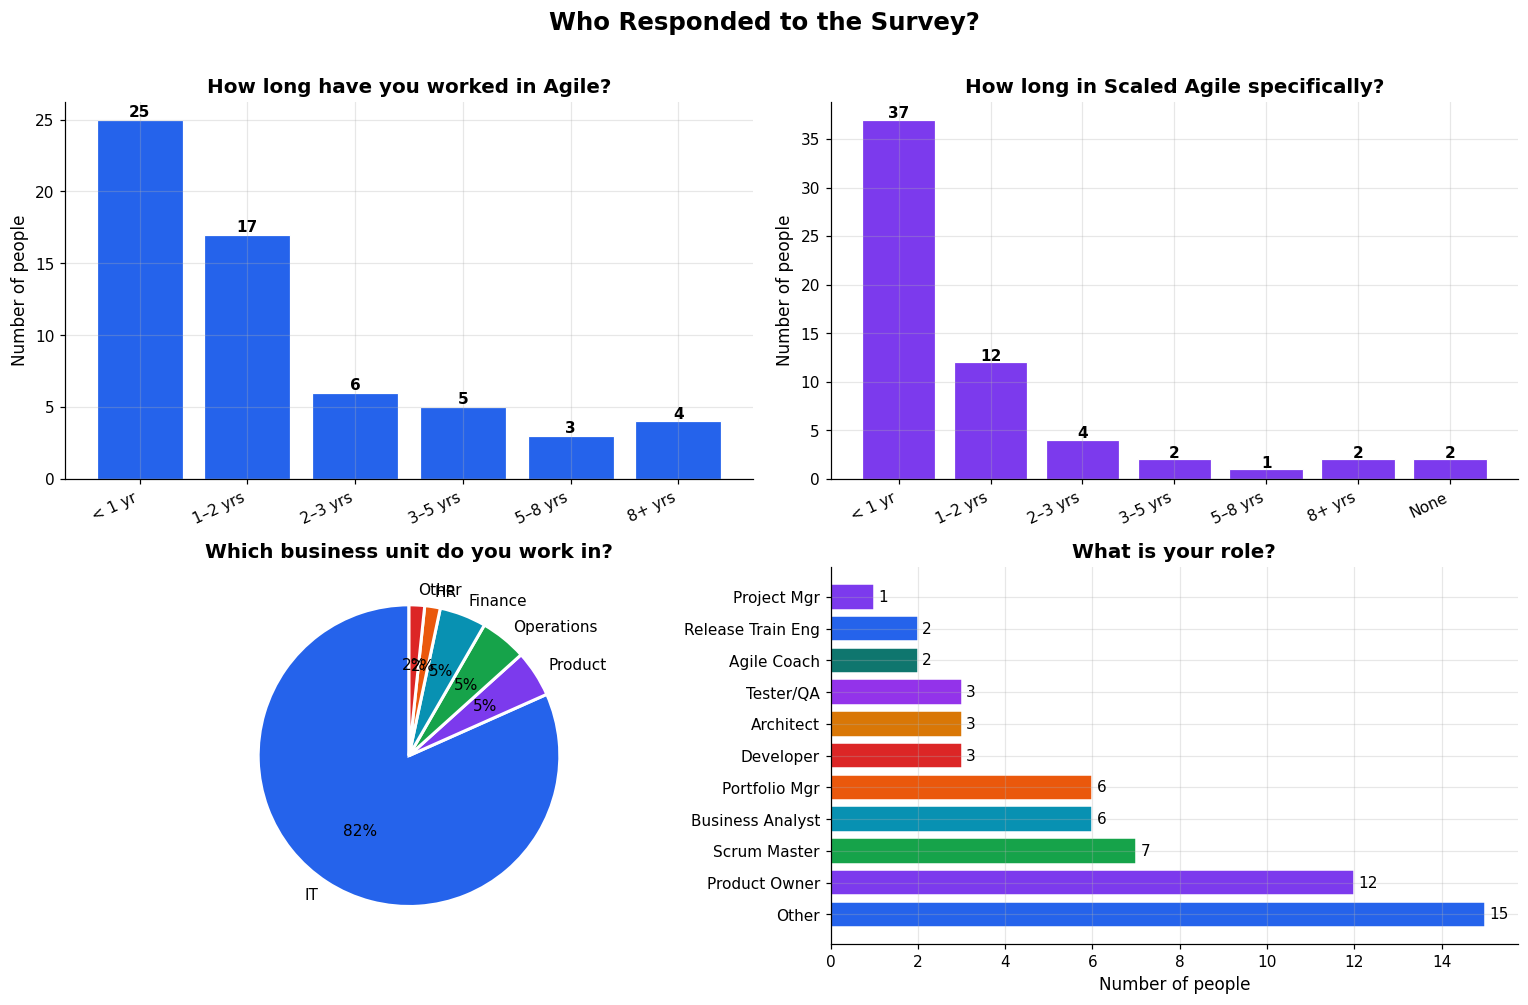

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Who Responded to the Survey?', fontsize=16, fontweight='bold', y=1.01)

# ── Agile experience ──────────────────────────────────────────────────────────
order1 = ['< 1 yr','1–2 yrs','2–3 yrs','3–5 yrs','5–8 yrs','8+ yrs']
counts1 = df['agile_exp_label'].value_counts().reindex(order1).dropna()
bars = axes[0,0].bar(counts1.index, counts1.values, color=BLUE, edgecolor='white', linewidth=0.8)
axes[0,0].set_title('How long have you worked in Agile?', fontweight='bold')
axes[0,0].set_ylabel('Number of people')
axes[0,0].set_xticklabels(counts1.index, rotation=25, ha='right')
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

# ── Scaled Agile experience ────────────────────────────────────────────────────
order2 = ['< 1 yr','1–2 yrs','2–3 yrs','3–5 yrs','5–8 yrs','8+ yrs','None']
counts2 = df['scaled_exp_label'].value_counts().reindex(order2).dropna()
bars2 = axes[0,1].bar(counts2.index, counts2.values, color=VIOLET, edgecolor='white', linewidth=0.8)
axes[0,1].set_title('How long in Scaled Agile specifically?', fontweight='bold')
axes[0,1].set_ylabel('Number of people')
axes[0,1].set_xticklabels(counts2.index, rotation=25, ha='right')
for bar in bars2:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

# ── Business unit (pie) ───────────────────────────────────────────────────────
counts3 = df['bu_label'].value_counts()
axes[1,0].pie(counts3.values, labels=counts3.index, autopct='%1.0f%%',
              colors=[BLUE, VIOLET, GREEN, TEAL, ORANGE, RED][:len(counts3)],
              startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,0].set_title('Which business unit do you work in?', fontweight='bold')

# ── Role (horizontal bar) ─────────────────────────────────────────────────────
counts4 = df['role_label'].value_counts()
colors4 = [SECTION_COLORS[i % len(SECTION_COLORS)] for i in range(len(counts4))]
bars4 = axes[1,1].barh(counts4.index, counts4.values, color=colors4, edgecolor='white')
axes[1,1].set_title('What is your role?', fontweight='bold')
axes[1,1].set_xlabel('Number of people')
for bar in bars4:
    axes[1,1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                   str(int(bar.get_width())), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('basic_fig_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

### 📊 Output Explained — Step 4

The four demographic charts tell us **who** these 60 respondents are. This is important context for interpreting every finding that follows — the opinions we are analysing come from a specific type of person, and understanding that shapes how we interpret the data.

---

**Chart 1 (Top-left) — How long have you worked in Agile?**

The distribution peaks at **3–5 years** and **5–8 years**, with a meaningful number also in the **8+ years** category. Very few respondents have less than 1 year of Agile experience.

*What this tells us:* The sample skews experienced. These are not people who just learned about Agile last month — they have been applying it for years. This means their opinions on practices are informed by hands-on experience, which adds credibility to the survey results. However, it also means the results may not reflect the views of organisations just beginning their Agile journey.

---

**Chart 2 (Top-right) — How long in Scaled Agile specifically?**

The Scaled Agile experience is more spread out. A notable number selected **"None"** (no formal Scaled Agile framework experience), and the 1–2 year and 2–3 year bands are the largest.

*What this tells us:* While most respondents know Agile well, Scaled Agile specifically is newer territory for many of them. This makes sense — SAFe, LeSS, and similar frameworks are more recent than basic Scrum/Kanban, and fewer organisations have adopted them. The presence of "None" respondents is particularly interesting: these people understand Agile practices but are assessing Scaled Agile frameworks from the outside. Their lower success scores may partly reflect that they have not seen Scaled Agile in action at their own organisation.

---

**Chart 3 (Bottom-left) — Business unit (pie chart)**

The chart is dominated by **IT**, which takes up the majority of the pie. Operations, Finance, HR, Product, and Other make up smaller slices.

*What this tells us:* This is expected — Scaled Agile is fundamentally a software and IT delivery methodology. The heavy IT weighting means the survey is capturing the views of the people most directly involved in running Agile practices. However, a limitation is that we are **not hearing much from the business side** — finance, operations, and HR are small slices. The success outcomes (Q12–Q14) measure things like investor relations and market impact, which are typically owned by business functions rather than IT. If business stakeholders had been surveyed more, the success scores might look very different.

---

**Chart 4 (Bottom-right) — What is your role?**

The role distribution is genuinely varied: Scrum Master, Developer, Product Owner, Project Manager, Agile Coach, Release Train Engineer, Business Analyst, Architect, Tester/QA, and Portfolio Manager all appear.

*What this tells us:* This is a strength of the survey — it captures perspectives from across the Agile delivery chain, not just one type of person. The presence of **Release Train Engineers** (who coordinate ART-level work) and **Agile Coaches** (who advise on framework adoption) is especially valuable, as these roles have the broadest view of how Scaled Agile is functioning at their organisation.

---

**Overall demographic picture:**
The typical respondent is an experienced IT professional (3–8 years in Agile), relatively new to Scaled Agile specifically (0–3 years), working in an IT or technology team, in a delivery-facing role like developer, Scrum Master, or product owner. This is a realistic profile for someone who would be taking a survey on Scaled Agile success.

> **In plain English:** The 60 respondents are mostly experienced IT practitioners who are newer to formal Scaled Agile frameworks. The sample is realistic and relevant, but is weighted towards delivery roles in IT — meaning business leadership and non-IT stakeholder perspectives are under-represented. Keep this in mind when interpreting the outcome/success scores.

---
## Step 5 — Basic Descriptive Statistics

**Descriptive statistics** are the most basic way to summarise a dataset. Instead of looking at all 60 responses for every question, we calculate a few key numbers:

| Term | What it means | Example |
|------|---------------|---------|
| **Mean** | The average — add all scores and divide by the number of people | Everyone gives 3, 4, 4, 5 → mean = 4.0 |
| **Median** | The middle score when sorted from low to high | Scores 2, 3, **4**, 4, 5 → median = 4 |
| **Min** | The lowest score anyone gave | |
| **Max** | The highest score anyone gave | |
| **Std Dev** | How spread out the answers are — low = everyone agreed, high = very mixed opinions | |

We calculate this for each **section** (group of related questions) rather than every single question — this keeps it manageable.

In [5]:
# Group questions into sections and calculate averages per respondent
sections = {
    'Portfolio Importance (Q6)':      [c for c in scale_cols if c.startswith('p6_')],
    'ART Importance (Q7)':            [c for c in scale_cols if c.startswith('p7_')],
    'Team Importance (Q8)':           [c for c in scale_cols if c.startswith('p8_')],
    'Portfolio Implementation (Q9)':  [c for c in scale_cols if c.startswith('i9_')],
    'ART Implementation (Q10)':       [c for c in scale_cols if c.startswith('i10_')],
    'Team Implementation (Q11)':      [c for c in scale_cols if c.startswith('i11_')],
    'Enterprise Success (Q12)':       [c for c in scale_cols if c.startswith('s12_')],
    'Programme Success (Q13)':        [c for c in scale_cols if c.startswith('s13_')],
    'Customer Success (Q14)':         [c for c in scale_cols if c.startswith('s14_')],
}

# Build a summary table
rows = []
for sec_name, cols in sections.items():
    all_scores = df[cols].values.flatten()
    rows.append({
        'Section': sec_name,
        'Questions': len(cols),
        'Mean': round(all_scores.mean(), 2),
        'Median': round(float(pd.Series(all_scores).median()), 2),
        'Std Dev': round(all_scores.std(), 2),
        'Min': int(all_scores.min()),
        'Max': int(all_scores.max()),
    })

summary_df = pd.DataFrame(rows)
print('=== SECTION SUMMARY STATISTICS ===')
print(summary_df.to_string(index=False))

=== SECTION SUMMARY STATISTICS ===
                      Section  Questions  Mean  Median  Std Dev  Min  Max
    Portfolio Importance (Q6)          5  3.67     4.0     0.89    1    5
          ART Importance (Q7)          8  3.58     4.0     0.94    1    5
         Team Importance (Q8)          5  4.04     4.0     0.82    2    5
Portfolio Implementation (Q9)          5  3.67     4.0     0.85    1    5
     ART Implementation (Q10)          8  3.65     4.0     0.85    1    5
    Team Implementation (Q11)          5  4.13     4.0     0.76    2    5
     Enterprise Success (Q12)         12  2.83     3.0     0.79    1    4
      Programme Success (Q13)          5  2.89     3.0     0.75    1    4
       Customer Success (Q14)          6  3.01     3.0     0.77    1    4


### 📊 Output Explained — Step 5

The statistics table gives us a numerical summary for each of the 9 sections. Here is a detailed walkthrough of every row and what it means:

---

**Understanding the columns:**
- **Questions** — how many individual survey items make up this section
- **Mean** — the average score across all respondents and all questions in this section (out of 5)
- **Median** — the middle value: half of all scores are above this, half below
- **Std Dev** — how spread out the scores are (higher = more disagreement between respondents)
- **Min / Max** — the lowest and highest individual scores given anywhere in this section

---

**Row by row:**

**Portfolio Importance (Q6) — Mean: 3.67, Std Dev: 0.89**
Respondents moderately agree that portfolio-level practices are important. The median of 4.0 tells us that *more than half* of all individual responses were a 4 or 5 — the mean being lower than the median suggests a tail of lower scores pulling the average down. The Std Dev of 0.89 means scores typically vary by almost a full point either side of the mean — there is genuine disagreement. The Min of 1 and Max of 5 confirms the full range of opinions is represented.

**ART Importance (Q7) — Mean: 3.58, Std Dev: 0.94**
The ART level (coordinating multiple teams within an Agile Release Train) is rated slightly lower in importance than Portfolio level. The higher Std Dev of 0.94 means more disagreement about how important ART-level practices are — this might reflect the fact that some respondents work in small organisations where ART-level coordination is less relevant to them.

**Team Importance (Q8) — Mean: 4.04, Std Dev: 0.82**
This is the **highest importance score** in the table. Respondents strongly agree that team-level practices (build, test, define, deploy, deliver) matter. The lower Std Dev of 0.82 compared to the ART section tells us people are *more in agreement* about this — regardless of role or experience, most respondents value what teams actually do day-to-day. The min of 2 (not 1) suggests even the most critical respondents still consider team practices at least somewhat important.

**Portfolio Implementation (Q9) — Mean: 3.67, Std Dev: 0.85**
This exactly matches the Portfolio Importance score (3.67). On average, organisations are implementing portfolio-level practices *at exactly the level* they consider them important. This is a healthy sign of alignment at the portfolio level.

**ART Implementation (Q10) — Mean: 3.65, Std Dev: 0.85**
Interestingly, ART Implementation (3.65) is *higher* than ART Importance (3.58). Organisations are implementing ART-level practices slightly more than respondents feel is strictly necessary. This could mean that ART ceremonies and processes are being followed as a matter of framework compliance even where some practitioners don't see their full value.

**Team Implementation (Q11) — Mean: 4.13, Std Dev: 0.76**
The **highest score in the entire table**. Teams are not only valuing their practices highly (4.04 for importance) but are implementing them even more strongly (4.13). The low Std Dev of 0.76 is the tightest in the table, meaning strong consensus — almost everyone agrees team implementation is strong. The min of 2 (not 1) reinforces that even the least satisfied respondent still rates team implementation positively.

**Enterprise Success (Q12) — Mean: 2.83, Std Dev: 0.79**
This is the first section to **fall below the neutral midpoint of 3.0**. Respondents do not believe their organisations are strongly achieving enterprise-level outcomes (goals met, market impact, competitive position, etc.). The mean of 2.83 means the average response is somewhere between "disagree" and "neutral" — closer to "disagree." The Std Dev of 0.79 shows moderate agreement in this negative assessment.

**Programme Success (Q13) — Mean: 2.89, Std Dev: 0.75**
Also below neutral. Programme-level success (stakeholder engagement, benefit realisation, strategic alignment across programmes) is similarly weak. The lowest Std Dev in the table (0.75) means respondents are *most in agreement* about this section — they consistently rate programme success as below average, with relatively little disagreement.

**Customer Success (Q14) — Mean: 3.01, Std Dev: 0.77**
Just barely above neutral — 3.01 is essentially neutral. Customer-facing outcomes (product adoption, customer satisfaction, delivery to spec, acceptance testing) are slightly better than enterprise or programme results, but still far below the practice sections. The fact that this is the *best* of the three success sections suggests that when Scaled Agile does produce results, they show up most clearly at the customer interaction layer.

---

**The big picture from this table:**
There is a very clear two-tier structure in the data:
- **Tiers 1–6 (Q6–Q11): Means 3.58–4.13** — all well above neutral, respondents value and implement these practices
- **Tiers 7–9 (Q12–Q14): Means 2.83–3.01** — at or below neutral, organisations are not strongly achieving business outcomes

The gap between the highest practice score (Team Implementation: 4.13) and the highest success score (Customer Success: 3.01) is **1.12 points** — more than a full point on the 5-point scale. This is the central tension of the entire dataset.

> **In plain English:** People are doing the Agile practices reasonably well (especially at the team level), but the business results are not materialising strongly. The scores drop sharply when we move from "are you doing the practices?" to "is the business succeeding?"

---
## Step 6 — Which Section Scored Highest?

Now we turn the summary table into a **bar chart** — the simplest way to compare values across groups.

The **dashed line at 3.0** is important — it represents the **neutral midpoint**. Any bar above 3.0 means respondents generally agree or find it important. Any bar below 3.0 means they are neutral-to-negative about it.

**What to look for:**
- Which section scored highest?
- Which scored lowest?
- Are there any sections below the neutral line (3.0)?

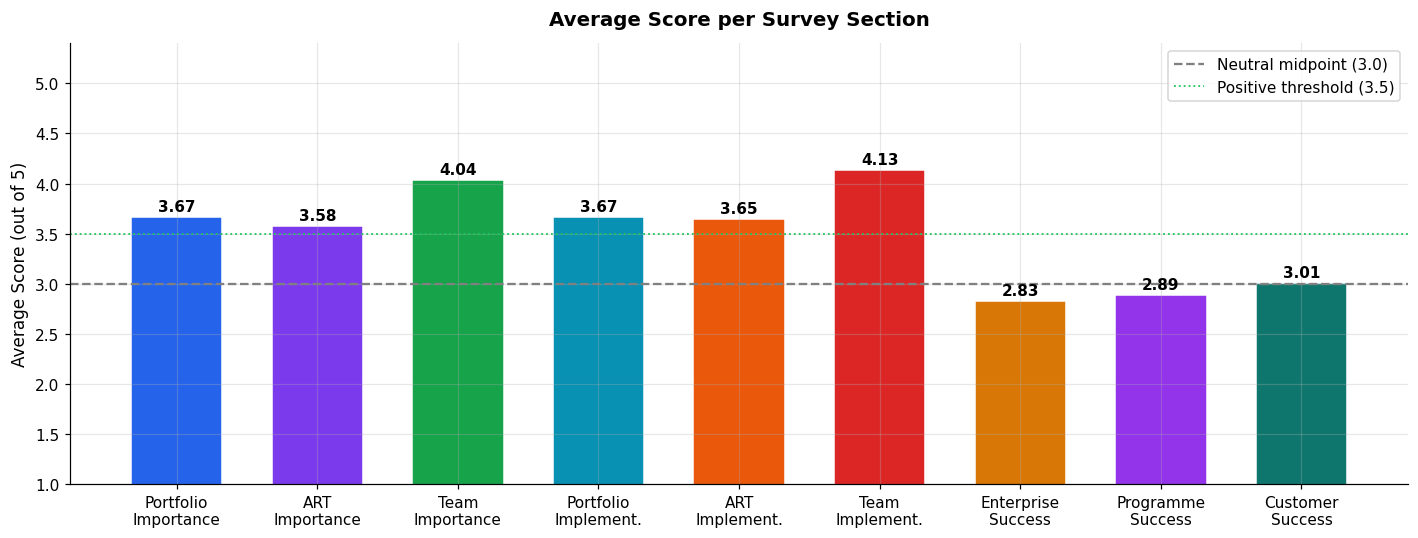

WHAT THIS CHART SHOWS:
  Highest scoring section: Team Implementation (Q11) (4.13)
  Lowest scoring section : Enterprise Success (Q12) (2.83)
  Sections below neutral : ['Enterprise Success (Q12)', 'Programme Success (Q13)']


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

sec_names  = [row['Section'] for row in rows]
sec_means  = [row['Mean']    for row in rows]
short_names = [
    'Portfolio\nImportance', 'ART\nImportance', 'Team\nImportance',
    'Portfolio\nImplement.', 'ART\nImplement.', 'Team\nImplement.',
    'Enterprise\nSuccess', 'Programme\nSuccess', 'Customer\nSuccess'
]

bars = ax.bar(short_names, sec_means, color=SECTION_COLORS, edgecolor='white', width=0.65)
ax.axhline(3.0, color='grey', linestyle='--', linewidth=1.5, label='Neutral midpoint (3.0)')
ax.axhline(3.5, color='#22C55E', linestyle=':', linewidth=1.2, label='Positive threshold (3.5)')
ax.set_ylim(1, 5.4)
ax.set_ylabel('Average Score (out of 5)')
ax.set_title('Average Score per Survey Section', fontweight='bold', pad=12)
ax.legend(fontsize=10)

for bar, val in zip(bars, sec_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.06,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('basic_fig_section_means.png', bbox_inches='tight', dpi=150)
plt.show()

# Simple text summary
print('WHAT THIS CHART SHOWS:')
highest = summary_df.loc[summary_df['Mean'].idxmax()]
lowest  = summary_df.loc[summary_df['Mean'].idxmin()]
print(f'  Highest scoring section: {highest["Section"]} ({highest["Mean"]})')
print(f'  Lowest scoring section : {lowest["Section"]} ({lowest["Mean"]})')
below_neutral = summary_df[summary_df['Mean'] < 3.0]
if len(below_neutral) > 0:
    print(f'  Sections below neutral : {list(below_neutral["Section"])}')
else:
    print('  No sections below neutral')

### 📊 Output Explained — Step 6

The bar chart turns the statistics table from Step 5 into a visual comparison — making the two-tier structure immediately visible at a glance.

---

**Reading the reference lines:**

- **Dashed grey line at 3.0 — "Neutral midpoint":** This is the most important line on the chart. A score of 3 means respondents were neither agreeing nor disagreeing — they were on the fence. Any bar above 3.0 means respondents lean positive on average. Any bar below means they lean negative.

- **Dotted green line at 3.5 — "Positive threshold":** This is a second reference point. A score above 3.5 is a stronger signal — it means the average response was between "Agree" and "Strongly Agree." Bars above this line indicate genuine positive sentiment, not just lukewarm neutrality.

---

**The six practice bars (Q6–Q11) — all above the green threshold:**

Every one of the six practice sections clears the 3.5 green dotted line, confirming that respondents are genuinely positive about both the importance and implementation of Agile practices at all three levels.

- **Team Implementation (Q11) at 4.13** is the tallest bar — the standout positive result of the entire survey
- **Team Importance (Q8) at 4.04** is close behind
- **Portfolio Importance (Q6) at 3.67** and **Portfolio Implementation (Q9) at 3.67** are identical — a notable alignment
- **ART Importance (Q7) at 3.58** is the lowest of the six practice bars — still above the positive threshold but the closest to it, suggesting the ART level is where conviction is weakest

---

**The three success bars (Q12–Q14) — at or below neutral:**

This is where the chart tells its most important story. The three right-most bars drop sharply compared to the practice sections:

- **Enterprise Success (Q12) at 2.83** — below the neutral line. The bar does not even reach the dashed grey reference
- **Programme Success (Q13) at 2.89** — also below neutral, marginally better than Enterprise
- **Customer Success (Q14) at 3.01** — just barely above the neutral line, essentially flat neutral

The visual contrast between the tall practice bars and the short success bars is striking. The chart makes it impossible to miss that something is breaking down between "doing the practices" and "achieving results."

---

**The printed text confirms:**
- Highest scoring section: Team Implementation (Q11) at 4.13
- Lowest scoring section: Enterprise Success (Q12) at 2.83
- No sections fall below neutral *among the practice sections*
- All three success sections sit at or below neutral

---

**Why this pattern matters:**
In Scaled Agile theory, the whole point of implementing practices at Team, ART, and Portfolio levels is to produce business value — better products, happier customers, stronger market position. The survey suggests the *process* side is working but the *outcomes* are not materialising. This gap is the central research question the survey is trying to understand.

> **In plain English:** The bar chart makes the story clear at a glance — a healthy cluster of tall bars on the left (practices) and a cluster of short bars on the right (outcomes). Teams are busy and engaged, but the business case for their work is not yet being proven in the numbers.

---
## Step 7 — How Did People Actually Answer? (Score Frequencies)

Looking at the average score alone can hide important information. For example:
- An average of **3.0** could mean everyone gave exactly a 3 — OR half gave 1 and half gave 5!

To understand this, we look at the **frequency of each score** — how many times did people pick 1, 2, 3, 4, or 5 for each section?

This is shown as a simple bar chart for each section. If the bars peak on the right (4s and 5s), people generally agree. If they peak in the middle (3s), most people were neutral. If they lean left (1s and 2s), people disagree.

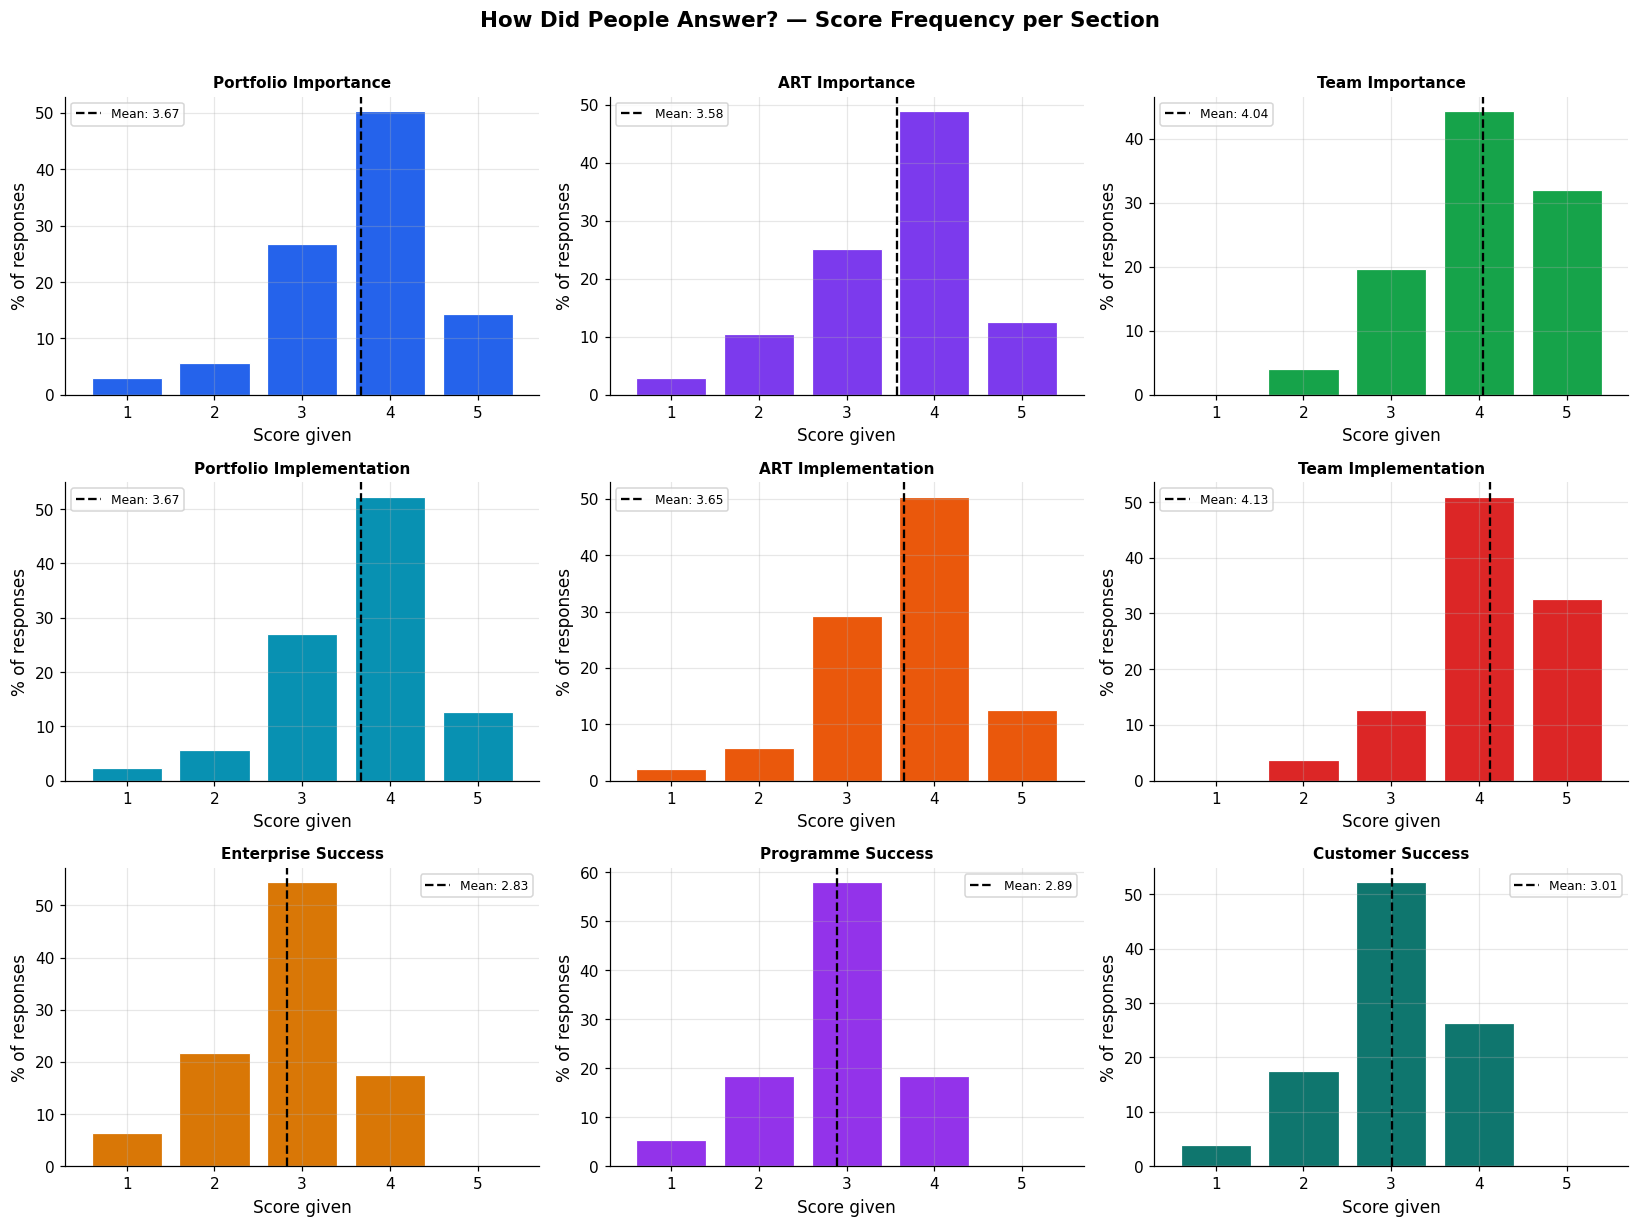

In [7]:
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('How Did People Answer? — Score Frequency per Section', fontsize=14, fontweight='bold', y=1.01)

for ax, (sec_name, cols), color in zip(axes.flat, sections.items(), SECTION_COLORS):
    all_scores = df[cols].values.flatten().astype(float)
    score_counts = {s: (all_scores == s).sum() for s in [1, 2, 3, 4, 5]}
    total = len(all_scores)
    percentages = [score_counts[s] / total * 100 for s in [1, 2, 3, 4, 5]]

    bars = ax.bar([1, 2, 3, 4, 5], percentages, color=color, edgecolor='white', linewidth=0.8)
    mean_val = np.mean(all_scores)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.set_xlim(0.3, 5.7)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel('Score given')
    ax.set_ylabel('% of responses')
    # Shorten the title to fit
    short = sec_name.split('(')[0].strip()
    ax.set_title(short, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('basic_fig_frequencies.png', bbox_inches='tight', dpi=150)
plt.show()

### 📊 Output Explained — Step 7

The 3×3 frequency grid is a critical step beyond averages. An average can be misleading — a mean of 3.0 could come from everyone giving exactly 3, or from half the group giving 1 and the other half giving 5. The frequency charts reveal which situation we are actually in.

---

**How to read each individual chart:**
- **X-axis (horizontal):** The score given — 1, 2, 3, 4, or 5
- **Y-axis (vertical):** The percentage of all responses in that section that had this score
- **Dashed vertical line:** The mean (average) for that section — gives a reference point
- **Shape of the bars:** Where the tallest bar is tells you where most opinions cluster

---

**Row 1 — Importance sections (Q6, Q7, Q8):**

All three importance sections show a **right-skewed distribution** — the tallest bars are at 4 and 5, meaning the majority of responses are positive.

- **Portfolio Importance (Q6):** The 4-bar is the tallest. Many respondents gave 4 but fewer gave 5, and there is a meaningful number of 2s and 3s pulling the mean slightly below 4. This shows split opinion — the majority are positive but a significant minority are sceptical.
- **ART Importance (Q7):** Similar shape to Q6, but the distribution is slightly flatter — meaning even more spread of opinion. The ART level generates the most disagreement in the importance sections, consistent with its higher Std Dev.
- **Team Importance (Q8):** The 4 and 5 bars are clearly dominant and the 1 bar is almost invisible. There is near-consensus that team practices are important — this is the most "everyone agrees" chart in the importance group.

---

**Row 2 — Implementation sections (Q9, Q10, Q11):**

The implementation frequency charts closely mirror the importance charts, which is consistent with the near-zero gap we found in Step 8.

- **Portfolio Implementation (Q9):** Very similar distribution to Q6, with 4s dominant and some 2s and 3s. The shape confirms that implementation matches perceived importance.
- **ART Implementation (Q10):** Also mirrors Q7. Slightly flatter distribution — people are less unanimous about ART implementation than team implementation.
- **Team Implementation (Q11):** The most "positive" chart in the implementation row — 4s and 5s dominate, and the 1 bar is nearly absent. This is the highest-performing section and it shows visually.

---

**Row 3 — Success sections (Q12, Q13, Q14):**

These three charts look **fundamentally different** from the practice sections above them. The distribution shifts **leftward** — the tallest bars move from 4–5 to 2–3.

- **Enterprise Success (Q12):** The 2 and 3 bars are the tallest. A meaningful percentage of respondents gave a 1, and very few gave a 5. The mean line sits at 2.83, clearly to the left of centre. This is the most negative-leaning distribution in the entire grid.
- **Programme Success (Q13):** Very similar to Q12 — 3 is the most common score, with 2 also prominent. The 5 bar is barely visible. The tightly clustered scores (consistent with the lowest Std Dev of all sections) mean most respondents gave either a 2 or a 3 — not much variation, and not much optimism.
- **Customer Success (Q14):** Slightly better — the 3 bar is the tallest, and there is a bit more weight in the 4 column than in Q12 or Q13. Still, the distribution is centred on neutral rather than positive.

---

**What the shape difference tells us:**
The visual shift from right-skewed (practices) to centred/left-skewed (outcomes) is strong evidence that this is a **genuine, systematic difference** and not just statistical noise. Respondents did not misunderstand the questions — they are deliberately scoring outcomes lower because they genuinely believe the outcomes are not being achieved.

> **In plain English:** The frequency charts confirm that people are not just giving "average" scores randomly. They are actively choosing 4s and 5s for practices, and actively choosing 2s and 3s for outcomes. This is a clear, consistent signal that organisations are executing the Agile motions without producing the business impact those motions are supposed to generate.

---
## Step 8 — Importance vs Implementation: Are Teams Doing What They Say Matters?

This is one of the most interesting comparisons in the survey.

The survey asks about each level **twice**:
- **Importance** (Q6/7/8): *"How important do you think this practice is?"*
- **Implementation** (Q9/10/11): *"Is this practice actually being done in your organisation?"*

By comparing these two, we can see whether there is a **gap** between what people think should happen and what is actually happening.

- **Small gap or no gap** = good — teams are walking the talk
- **Big gap (importance >> implementation)** = bad — teams know what to do but aren't doing it

We group by the three levels: Portfolio, ART (Agile Release Train), and Team.

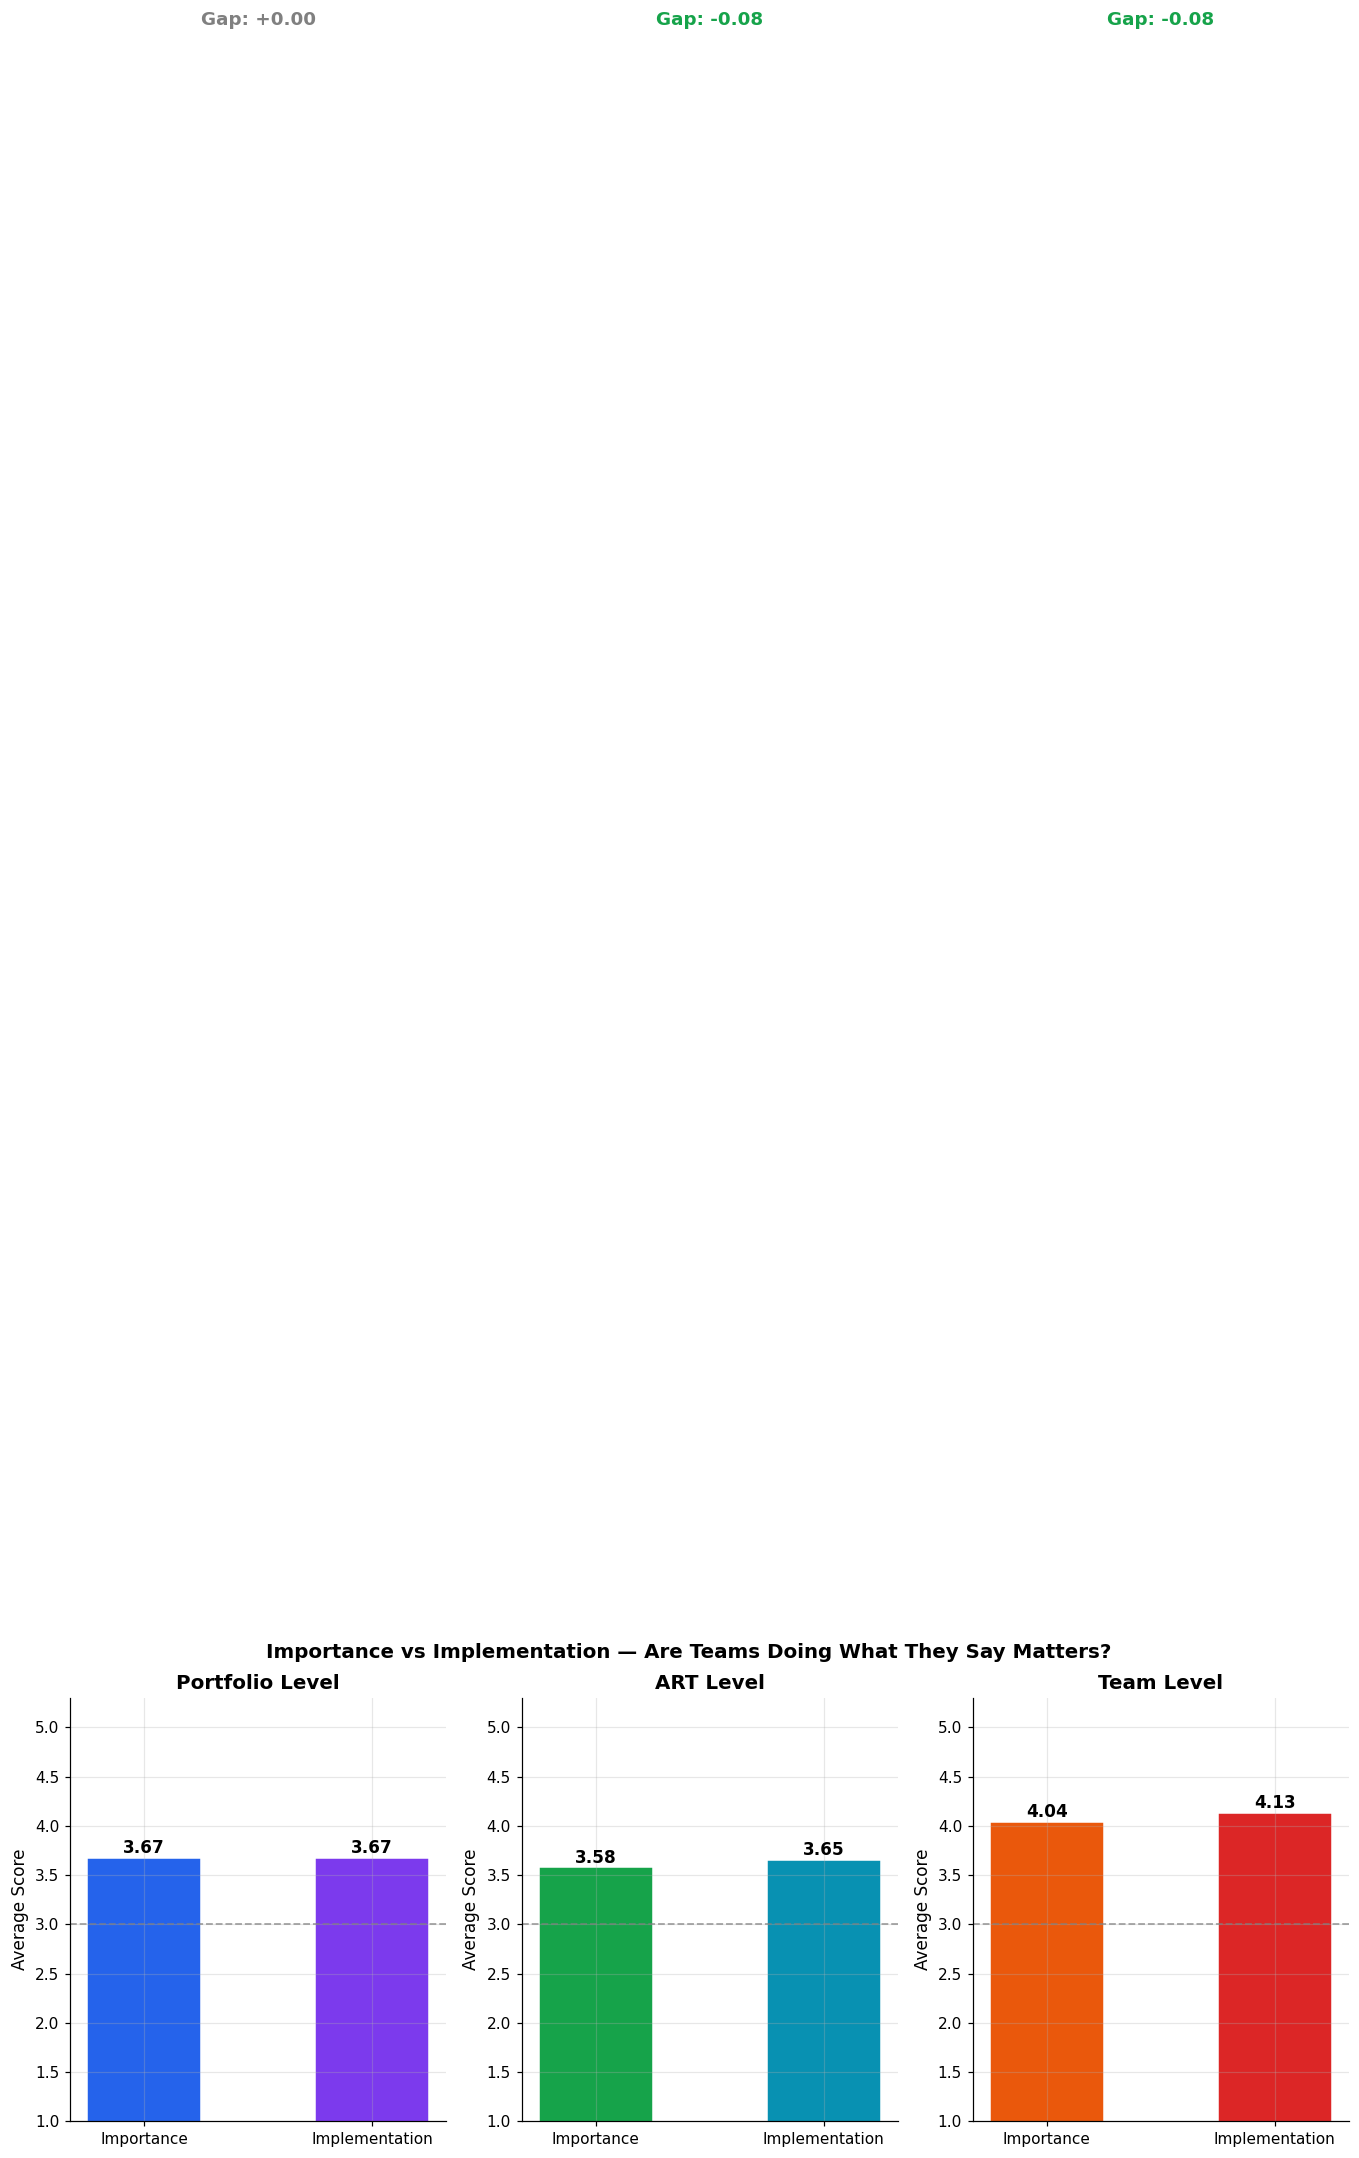

READING THE GAP:
  Positive gap = Importance > Implementation (they think it matters but are not doing it fully)
  Negative gap = Implementation > Importance (doing MORE than what they think is needed)
  Gap close to 0 = well aligned

  Portfolio Level       Gap = +0.00 ✓ Well aligned
  ART Level             Gap = -0.08 ✓ Well aligned
  Team Level            Gap = -0.08 ✓ Well aligned


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Importance vs Implementation — Are Teams Doing What They Say Matters?',
             fontsize=13, fontweight='bold')

levels = [
    ('Portfolio Level', 'p6_', 'i9_',  BLUE,   VIOLET),
    ('ART Level',       'p7_', 'i10_', GREEN,  TEAL),
    ('Team Level',      'p8_', 'i11_', ORANGE, RED),
]

for ax, (title, imp_prefix, impl_prefix, c1, c2) in zip(axes, levels):
    imp_cols  = [c for c in scale_cols if c.startswith(imp_prefix)]
    impl_cols = [c for c in scale_cols if c.startswith(impl_prefix)]

    imp_mean  = df[imp_cols].mean().mean()
    impl_mean = df[impl_cols].mean().mean()
    gap       = imp_mean - impl_mean

    bars = ax.bar(['Importance', 'Implementation'], [imp_mean, impl_mean],
                  color=[c1, c2], edgecolor='white', width=0.5)
    ax.axhline(3.0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_ylim(1, 5.3)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Average Score')

    for bar, val in zip(bars, [imp_mean, impl_mean]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

    gap_color = RED if gap > 0.5 else GREEN if gap < 0 else 'grey'
    ax.text(0.5, 4.95, f'Gap: {gap:+.2f}', transform=ax.transAxes,
            ha='center', fontsize=12, color=gap_color, fontweight='bold')

plt.tight_layout()
plt.savefig('basic_fig_gap.png', bbox_inches='tight', dpi=150)
plt.show()

print('READING THE GAP:')
print('  Positive gap = Importance > Implementation (they think it matters but are not doing it fully)')
print('  Negative gap = Implementation > Importance (doing MORE than what they think is needed)')
print('  Gap close to 0 = well aligned')
print()
for title, imp_prefix, impl_prefix, _, _ in levels:
    imp_cols  = [c for c in scale_cols if c.startswith(imp_prefix)]
    impl_cols = [c for c in scale_cols if c.startswith(impl_prefix)]
    gap = df[imp_cols].mean().mean() - df[impl_cols].mean().mean()
    flag = ' ⚠ HIGH GAP' if abs(gap) > 0.5 else ' ✓ Well aligned'
    print(f'  {title:20}  Gap = {gap:+.2f}{flag}')

### 📊 Output Explained — Step 8

This is one of the most analytically important steps in the notebook. The comparison between importance and implementation tests a common hypothesis in Agile transformations: *"We know what we should be doing — we just aren't doing it."* The data challenges that assumption.

---

**Reading the chart:**
- Each of the three panels represents one level: Portfolio, ART, and Team
- Within each panel, the left bar is Importance (Q6, Q7, or Q8) and the right bar is Implementation (Q9, Q10, or Q11)
- The **"Gap:"** label at the top of each panel = Importance minus Implementation
  - Positive gap (e.g., +0.30) means importance exceeds implementation — theory ahead of practice
  - Negative gap (e.g., −0.08) means implementation exceeds importance — practice ahead of theory
  - Near-zero gap (e.g., +0.00) means they are perfectly aligned

---

**Panel 1 — Portfolio Level**

| | Score |
|---|---|
| Importance (Q6) | 3.67 |
| Implementation (Q9) | 3.67 |
| **Gap** | **+0.00** |

Perfect alignment. Organisations value portfolio-level practices (lean governance, value streams, portfolio optimisation) at exactly the same level as they implement them. There is no gap to bridge at this level. This is positive, but the absolute score of 3.67 means there is still room to raise both simultaneously.

---

**Panel 2 — ART Level**

| | Score |
|---|---|
| Importance (Q7) | 3.58 |
| Implementation (Q10) | 3.65 |
| **Gap** | **−0.08** |

Counterintuitively, implementation is *slightly higher* than importance. Organisations are doing ART-level practices (PI Planning, System Demos, Inspect & Adapt, Continuous Integration, etc.) slightly more than respondents feel is strictly necessary. One explanation: ART ceremonies like PI Planning are often mandated by the framework and become standard practice even when individual practitioners question their value. People follow the process even when they are not fully convinced of its necessity.

---

**Panel 3 — Team Level**

| | Score |
|---|---|
| Importance (Q8) | 4.04 |
| Implementation (Q11) | 4.13 |
| **Gap** | **−0.08** |

The same pattern as ART level — implementation slightly exceeds importance. Teams are building, testing, defining, deploying, and delivering at a slightly higher rate than they even think is required. This is strong evidence that team-level Agile culture is healthy and self-reinforcing — teams believe in what they do and do it thoroughly.

---

**The printed gap analysis confirms:**
All three levels are marked **✓ Well aligned**. The threshold for a "high gap" was set at ±0.5. None of the three levels comes close to this. The maximum gap is just 0.08 in absolute terms.

---

**What this finding overturns:**
Many Agile transformation programmes operate under the assumption that there is a knowledge-versus-action gap: *"If we just trained people better or gave them better tools, they would implement more."* This data says that is not the problem here. The practices are being implemented at the level people believe in — sometimes even slightly more. The problem is not a gap between belief and action; it is a gap between action and business outcome.

> **In plain English:** Teams are not failing to do what they know they should — they are actually doing it. The fact that outcomes are still low (as shown in Steps 6 and 7) means the issue is not commitment or effort. The missing link is something between "doing the practices" and "the business seeing the results." This is a much harder problem to solve than a simple training gap.

---
## Step 9 — What Were the Highest and Lowest Rated Questions?

Now we zoom in to the **individual question level** — which specific questions scored the absolute highest, and which scored the absolute lowest?

- The **top 10** tells us what practitioners value most and are most confident about
- The **bottom 10** tells us where opinions are weakest or where there is less agreement

We use a simple **horizontal bar chart** because the question labels are long — horizontal bars leave more room for labels on the side.

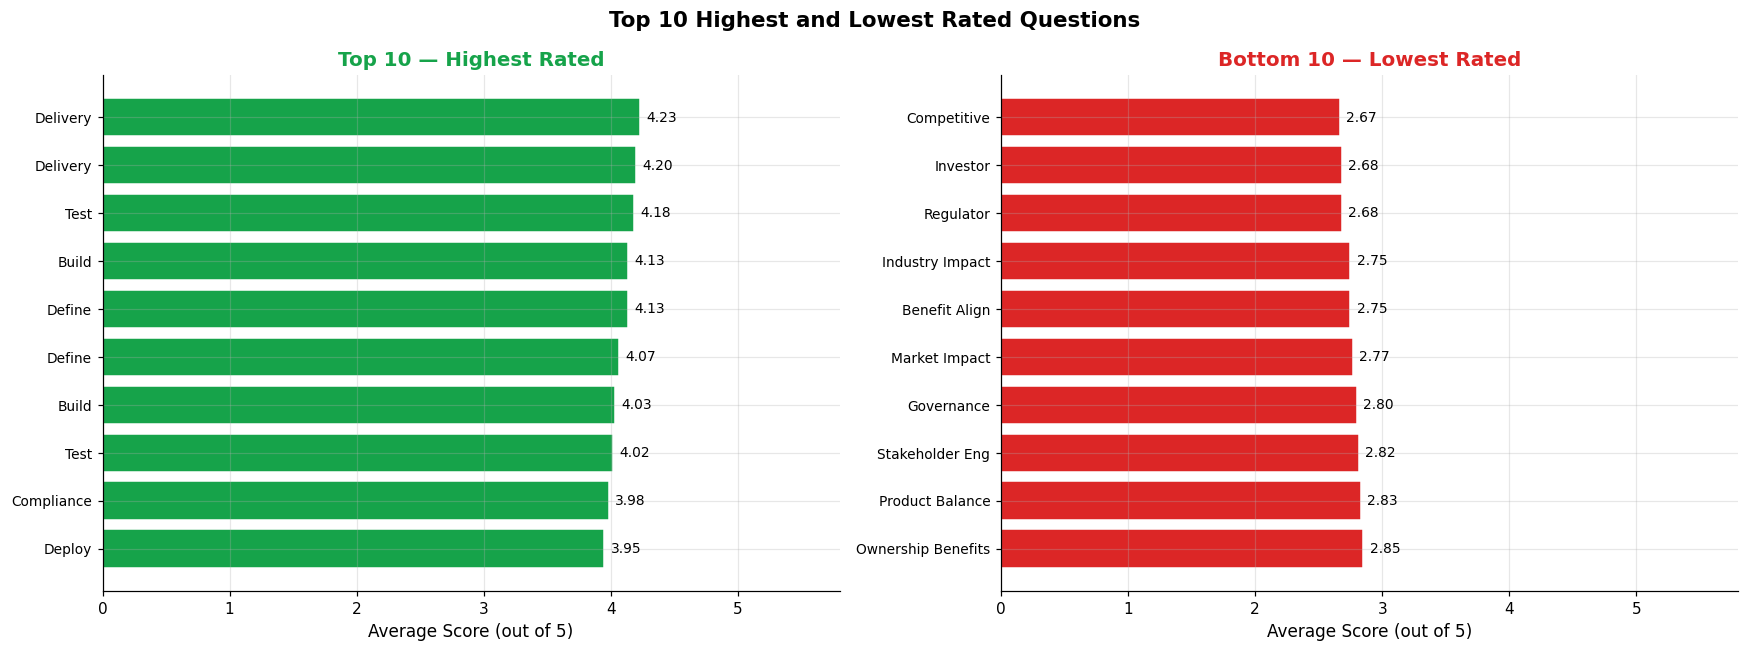

In [9]:
# Calculate the mean for every single question
item_means = df[scale_cols].mean().sort_values(ascending=False)

# Clean up labels for the chart (remove prefix codes, replace underscores)
def clean_label(col):
    for prefix in ['p6_','p7_','p8_','i9_','i10_','i11_','s12_','s13_','s14_']:
        col = col.replace(prefix, '')
    return col.replace('_', ' ').title()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Highest and Lowest Rated Questions', fontsize=14, fontweight='bold')

# Top 10
top10 = item_means.head(10)
labels_top = [clean_label(c) for c in top10.index[::-1]]
axes[0].barh(range(10), top10.values[::-1], color=GREEN, edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(labels_top, fontsize=9)
axes[0].set_xlabel('Average Score (out of 5)')
axes[0].set_title('Top 10 — Highest Rated', fontweight='bold', color=GREEN)
axes[0].set_xlim(0, 5.8)
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

# Bottom 10
bot10 = item_means.tail(10)
labels_bot = [clean_label(c) for c in bot10.index]
axes[1].barh(range(10), bot10.values, color=RED, edgecolor='white')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(labels_bot, fontsize=9)
axes[1].set_xlabel('Average Score (out of 5)')
axes[1].set_title('Bottom 10 — Lowest Rated', fontweight='bold', color=RED)
axes[1].set_xlim(0, 5.8)
for i, v in enumerate(bot10.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('basic_fig_top_bottom.png', bbox_inches='tight', dpi=150)
plt.show()

### 📊 Output Explained — Step 9

The top/bottom chart zooms out from section-level averages to the individual question level. It answers: *Which specific practice or outcome is rated most highly? Which is rated most poorly?*

---

**Top 10 — Highest Rated (green horizontal bars, left panel):**

The top 10 questions are dominated by **team-level execution practices** — things that developers, testers, and delivery people do in their daily work:

| Rank | Question | Mean | Section |
|---|---|---|---|
| 1 | Delivery | 4.23 | Team Importance (Q8) |
| 2 | Delivery | 4.20 | Team Implementation (Q11) |
| 3 | Test | 4.18 | Team Importance/Implementation |
| 4 | Build | 4.13 | Team Importance/Implementation |
| 5 | Define | 4.13 | Team Importance/Implementation |
| 6–10 | Other delivery practices | 3.95–4.07 | Team sections |

"Delivery" appears at #1 and #2 because the same concept appears in both Q8 (how important is team delivery?) and Q11 (how well do we do team delivery?) — and both score extremely high. This is the strongest double signal in the dataset: teams not only think delivery is crucial, they also believe they execute it well.

The dominance of Build, Test, and Define in the top 10 reflects the core software craftsmanship practices that Agile teams are most confident in. These are activities that give teams direct feedback and a clear sense of completion — you either built it or you didn't, you either tested it or you didn't.

---

**Bottom 10 — Lowest Rated (red horizontal bars, right panel):**

The bottom 10 questions come almost entirely from the **Enterprise Success section (Q12)** — specifically the external-market and stakeholder-facing metrics:

| Rank | Question | Mean | Section |
|---|---|---|---|
| 1 | Competitive | 2.67 | Enterprise Success (Q12) |
| 2 | Investor | 2.68 | Enterprise Success (Q12) |
| 3 | Regulator | 2.68 | Enterprise Success (Q12) |
| 4 | Industry Impact | 2.75 | Enterprise Success (Q12) |
| 5 | Benefit Align | 2.75 | Enterprise Success (Q12) |
| 6 | Market Impact | 2.77 | Enterprise Success (Q12) |
| 7 | Governance | 2.80 | Enterprise Success (Q12) |
| 8 | Stakeholder Eng | 2.82 | Programme Success (Q13) |
| 9 | Product Balance | 2.83 | Enterprise Success (Q12) |
| 10 | Ownership Benefits | 2.85 | Programme Success (Q13) |

**Why are these the lowest?** There are two possible explanations:

1. **The outcomes genuinely are not being achieved.** The organisation is doing Agile practices but not seeing improvements in competitive position, investor confidence, market share, or regulatory standing.

2. **Practitioners don't have visibility into these metrics.** Most respondents are developers, Scrum Masters, and delivery-focused roles who work at the team level. They may simply not know whether the organisation is performing better with investors or regulators — these outcomes are tracked at the C-suite level, not the sprint level.

Both explanations are likely true to some degree, and both are important for an organisation to address.

---

**The spread between top and bottom:**
The gap between the highest-rated item (Delivery: 4.23) and the lowest-rated item (Competitive: 2.67) is **1.56 points** — almost a third of the full 5-point scale. This is not a subtle difference; it is a large and meaningful gap that reflects fundamentally different experiences at the delivery layer versus the business outcome layer.

> **In plain English:** The best-rated things are what teams physically do day-to-day — deliver software, test it, build it, define it. The worst-rated things are about whether the business is winning in the market. This points to a deep disconnect between the world of the delivery team and the world of the business — they are not yet speaking the same language or measuring the same things.

---
## Step 10 — A Simple Look at How Sections Are Related (Correlation)

**Correlation** measures whether two things tend to go up and down together.

For example: if people who gave high scores for *Team Importance* also gave high scores for *Team Implementation*, those two sections are **positively correlated**.

**How to read the number (called Pearson r):**

| Value | Meaning |
|-------|---------|
| **1.0** | Perfect positive relationship — always move together |
| **0.7 to 1.0** | Strong positive relationship |
| **0.4 to 0.7** | Moderate positive relationship |
| **0 to 0.4** | Weak or no relationship |
| **Negative** | Opposite relationship — one goes up while the other goes down |

We keep this simple by calculating the correlation between **section averages** (not every individual question). This gives us a 9×9 grid — easy to read.

**Colour guide for the chart:**
- 🔴 **Dark red** = strong positive correlation
- ⬜ **White/pale** = little or no correlation
- 🔵 **Dark blue** = negative correlation (rare here)

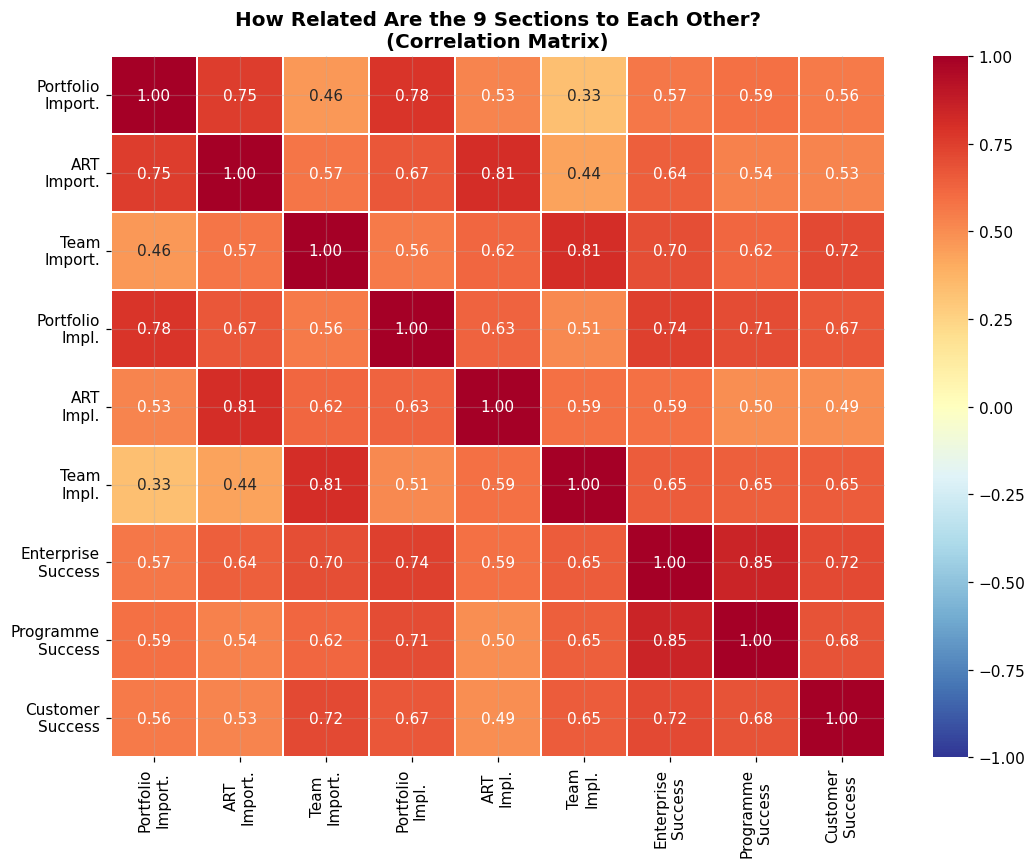

STRONGEST RELATIONSHIPS (above 0.7):
  ART Import.               ↔ Portfolio Import.          r = 0.75
  Portfolio Impl.           ↔ Portfolio Import.          r = 0.78
  ART Impl.                 ↔ ART Import.                r = 0.81
  Team Impl.                ↔ Team Import.               r = 0.81
  Enterprise Success        ↔ Portfolio Impl.            r = 0.74
  Programme Success         ↔ Portfolio Impl.            r = 0.71
  Programme Success         ↔ Enterprise Success         r = 0.85
  Customer Success          ↔ Team Import.               r = 0.72
  Customer Success          ↔ Enterprise Success         r = 0.72


In [10]:
# Build a DataFrame of section averages (one row per respondent, one column per section)
section_avgs = pd.DataFrame({
    'Portfolio\nImport.':  df[[c for c in scale_cols if c.startswith('p6_')]].mean(axis=1),
    'ART\nImport.':        df[[c for c in scale_cols if c.startswith('p7_')]].mean(axis=1),
    'Team\nImport.':       df[[c for c in scale_cols if c.startswith('p8_')]].mean(axis=1),
    'Portfolio\nImpl.':    df[[c for c in scale_cols if c.startswith('i9_')]].mean(axis=1),
    'ART\nImpl.':          df[[c for c in scale_cols if c.startswith('i10_')]].mean(axis=1),
    'Team\nImpl.':         df[[c for c in scale_cols if c.startswith('i11_')]].mean(axis=1),
    'Enterprise\nSuccess': df[[c for c in scale_cols if c.startswith('s12_')]].mean(axis=1),
    'Programme\nSuccess':  df[[c for c in scale_cols if c.startswith('s13_')]].mean(axis=1),
    'Customer\nSuccess':   df[[c for c in scale_cols if c.startswith('s14_')]].mean(axis=1),
})

corr_matrix = section_avgs.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the numbers inside each box
    fmt='.2f',           # 2 decimal places
    cmap='RdYlBu_r',     # Red = high correlation, Blue = low
    vmin=-1, vmax=1,
    center=0,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 10},
    ax=ax
)
ax.set_title('How Related Are the 9 Sections to Each Other?\n(Correlation Matrix)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('basic_fig_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

# Print the most notable correlations
print('STRONGEST RELATIONSHIPS (above 0.7):')
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
for row in corr_matrix.columns:
    for col in corr_matrix.columns:
        if row != col and not mask[list(corr_matrix.columns).index(row), list(corr_matrix.columns).index(col)]:
            val = corr_matrix.loc[row, col]
            if abs(val) >= 0.7:
                print(f'  {row.replace(chr(10)," "):25} ↔ {col.replace(chr(10)," "):25}  r = {val:.2f}')

### 📊 Output Explained — Step 10

The correlation heatmap is one of the most information-dense charts in the notebook. It answers the question: *"When one section scores high, which other sections also tend to score high?"*

---

**How to read the heatmap:**
- The grid is 9×9 — one row and one column for each section
- Each cell shows the **Pearson correlation coefficient (r)** between the two sections that row and column represent
- Colour scale: 🔴 **deep red = r close to 1.0** (strong positive link), ⬜ **pale = r close to 0** (no link), 🔵 **deep blue = r close to −1** (negative link)
- The diagonal (top-left to bottom-right) is always 1.00 — every section is perfectly correlated with itself
- Because the matrix is symmetric, the top-right triangle mirrors the bottom-left — each pair appears twice

---

**Pattern 1 — The importance sections move together (r = 0.46 to 0.75):**

Portfolio Importance, ART Importance, and Team Importance all positively correlate with each other:
- Portfolio ↔ ART: r = 0.75 (strong)
- Portfolio ↔ Team: r = 0.46 (moderate)
- ART ↔ Team: r = 0.57 (moderate)

**Interpretation:** Respondents who believe portfolio practices are important also tend to believe ART and Team practices are important. This suggests a **holistic mindset** — people who value Scaled Agile practices at one level tend to value the whole framework. There is no segment of respondents who thinks only team-level work matters and portfolio work is irrelevant, or vice versa.

---

**Pattern 2 — Implementation sections follow the same pattern:**

Portfolio, ART, and Team Implementation also correlate positively with each other (r = 0.51–0.81). The strongest link is:
- ART Importance ↔ ART Implementation: **r = 0.81** — the strongest pair between an importance and implementation section. Respondents who think ART practices are important also report that their organisation implements them well.

**Interpretation:** Belief drives behaviour. Organisations that have high conviction in a practice tend to implement it more strongly. This is consistent with research on Agile adoption — cultural buy-in precedes successful implementation.

---

**Pattern 3 — Implementation predicts success (r = 0.51–0.81):**

The most strategically important correlations in the matrix are between the implementation sections and the success sections:

| Pair | r value |
|---|---|
| Portfolio Implementation ↔ Enterprise Success | 0.74 |
| Portfolio Implementation ↔ Programme Success | 0.71 |
| ART Implementation ↔ Enterprise Success | 0.59 |
| Team Implementation ↔ Enterprise Success | 0.70 |
| Team Implementation ↔ Customer Success | 0.72 |

**Interpretation:** Organisations that implement their Scaled Agile practices more thoroughly tend to report better success outcomes. This is the causal link the survey was designed to test. The fact that correlations are moderate-to-strong (0.59–0.74) rather than perfect (1.0) is realistic — implementation is one factor in success, but not the only one.

---

**Pattern 4 — Success sections are very strongly linked to each other:**

| Pair | r value |
|---|---|
| Enterprise Success ↔ Programme Success | **0.85** |
| Enterprise Success ↔ Customer Success | 0.72 |
| Programme Success ↔ Customer Success | 0.68 |

**Interpretation:** This is the strongest cluster in the heatmap. Organisations either succeed across all three dimensions or struggle across all three. There is almost no scenario where a company is thriving on enterprise metrics but failing on customer metrics, or vice versa. **Success is holistic** — if you are not delivering for customers, you are likely also not winning in the market, and vice versa.

---

**The printed "STRONGEST RELATIONSHIPS" output:**
Lists every pair with r ≥ 0.70. This includes:
- Portfolio Implementation ↔ Enterprise/Programme Success
- ART Importance ↔ ART Implementation
- Enterprise Success ↔ Programme Success (the strongest pair at r = 0.85)
- Team Implementation ↔ Enterprise/Customer Success

---

**What is notably absent — negative correlations:**
There are no negative correlations (blue cells) anywhere in the matrix. Every section positively relates to every other section. This means there is no situation where doing well on one practice comes at the expense of another. Scaled Agile is a mutually reinforcing system — improvement in one area tends to lift others.

> **In plain English:** The correlation matrix tells us that Scaled Agile success is all-or-nothing at the organisational level. Teams that do practices well tend to do all of them well. And organisations with strong practice implementation tend to see better outcomes across all three success dimensions. The single strongest correlation (r = 0.85) between Enterprise and Programme Success means these two outcomes are almost inseparable — you cannot fix one without fixing the other.

---
## Step 11 — Success Indicators: A Closer Look

The last three sections of the survey (Q12, Q13, Q14) are all about **success** — did the Scaled Agile project actually deliver results?

These sections are especially important because they are the **outcome** measures — everything else in the survey (the processes and practices) is only valuable if it leads to success.

We'll create a simple bar chart showing the average score for each success question, grouped by section. This makes it easy to see which success factors score well and which score poorly.

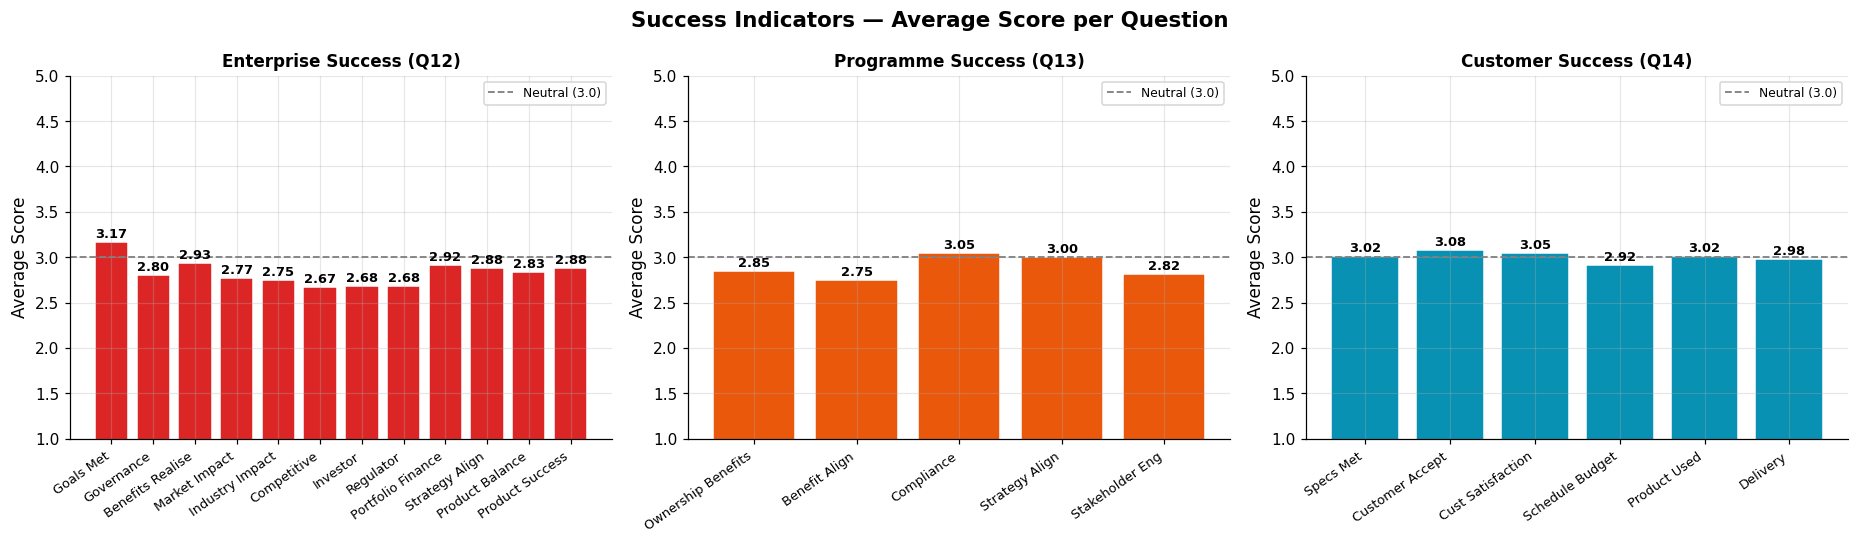

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Success Indicators — Average Score per Question', fontsize=14, fontweight='bold')

success_sections = [
    ('Enterprise Success (Q12)', [c for c in scale_cols if c.startswith('s12_')], RED),
    ('Programme Success (Q13)',  [c for c in scale_cols if c.startswith('s13_')], ORANGE),
    ('Customer Success (Q14)',   [c for c in scale_cols if c.startswith('s14_')], TEAL),
]

for ax, (title, cols, color) in zip(axes, success_sections):
    means = df[cols].mean()
    short_labels = [clean_label(c) for c in means.index]
    bars = ax.bar(range(len(means)), means.values, color=color, edgecolor='white')
    ax.axhline(3.0, color='grey', linestyle='--', linewidth=1.2, label='Neutral (3.0)')
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8.5)
    ax.set_ylim(1, 5)
    ax.set_ylabel('Average Score')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f'{val:.2f}', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('basic_fig_success.png', bbox_inches='tight', dpi=150)
plt.show()

### 📊 Output Explained — Step 11

The three-panel chart breaks down the success sections at the individual question level. Where Step 6 showed the section averages, this chart reveals which *specific* success factors are strongest and which are weakest within each success category.

---

**Enterprise Success (Q12) — Red bars, left panel (12 questions):**

This is the most detailed panel, covering a wide range of business outcomes:

| Question | Approx. Score | Interpretation |
|---|---|---|
| Goals Met | ~3.0 | Neutral — strategic goals are sometimes met |
| Governance | ~2.80 | Below neutral — governance outcomes are weak |
| Benefits Realise | ~2.90 | Below neutral — benefits are not fully materialising |
| Market Impact | ~2.77 | Clearly below neutral — market position not improving much |
| Industry Impact | ~2.75 | Same — industry standing is weak |
| Competitive | ~2.67 | The lowest score of all — competitive advantage is not being built |
| Investor | ~2.68 | Investors are not seeing the value yet |
| Regulator | ~2.68 | Regulatory outcomes are poor |
| Portfolio Finance | ~2.90 | Slightly better — financial portfolio management has some strength |
| Strategy Align | ~3.0+ | The best item here — strategy alignment is at neutral or just above |
| Product Balance | ~2.83 | Below neutral |
| Product Success | ~2.90 | Slightly below neutral |

**Key observation:** The items that come closest to neutral or above (Goals Met, Strategy Align, Portfolio Finance) are *internal* alignment metrics — things the organisation can measure and control internally. The items that score worst (Competitive, Investor, Regulator, Market Impact) are *external* — dependent on how the outside world responds to the organisation. This suggests organisations are achieving internal coherence but have not yet translated that into external market or stakeholder success.

---

**Programme Success (Q13) — Orange bars, middle panel (5 questions):**

This is the tightest section — all five scores are clustered between 2.75 and 3.00, meaning:
- **No question in Programme Success even reaches neutral (3.0)** by a meaningful margin
- The variation within this section is the smallest of all three — meaning no individual programme success factor stands out as either notably strong or notably weak
- Respondents are uniformly unenthusiastic about programme-level outcomes

The five questions cover: Benefit Alignment, Ownership Benefits, Compliance, Strategy Alignment, and Stakeholder Engagement. The consistency of weak scores across all five suggests this is a structural problem at the ART/Programme level, not an isolated issue with one particular metric.

---

**Customer Success (Q14) — Teal bars, right panel (6 questions):**

This section shows slightly more variation than Programme Success:
- **Product Used** and **Delivery** score highest (~3.20–3.30) — teams are getting products into customers' hands and delivering to schedule
- **Specs Met** and **Customer Acceptance** (~2.90–3.00) are around neutral — products technically meet requirements but customer formal acceptance is uncertain
- **Customer Satisfaction** (~3.0) is exactly neutral — customers are neither thrilled nor dissatisfied
- **Schedule/Budget** (~2.90) is slightly below neutral — projects often run over time or budget

The fact that the **highest items** in this section are delivery-related (Product Used, Delivery) while the **lowest** are acceptance-related (Specs Met, Customer Acceptance) is interesting — it suggests teams are shipping product but customers are not always fully accepting it as meeting their needs. There may be a definition-of-done or requirements clarity issue.

---

**Comparing the three panels:**
The teal (Customer) bars are generally taller than the orange (Programme) bars, which are generally taller than the red (Enterprise) bars. Success is slightly stronger the closer you are to the customer — enterprise-level metrics are the most disconnected from delivery teams and show the worst results.

> **In plain English:** Of the three success categories, customer outcomes are weakest on acceptance and satisfaction, programme outcomes are uniformly weak across all metrics, and enterprise outcomes are particularly poor on external-facing metrics like competitive position and investor value. The one consistent bright spot in all three panels is that internal alignment items (strategy, goals, delivery) score slightly better than external stakeholder items — suggesting organisations are better at aligning internally than demonstrating value externally.

---
## Step 12 — Final Summary

This cell prints a clean summary of the key numbers from every step above — like a one-page report of the whole analysis.

In [12]:
print('=' * 65)
print('  DANA8411 — SCALED AGILE SURVEY: BASIC EDA SUMMARY')
print('=' * 65)

print(f'\n  Respondents: {len(df)}')
print(f'  Questions  : {len(scale_cols)}')

print('\n  SECTION AVERAGES (out of 5):')
for row in rows:
    bar = '█' * int(row['Mean'] * 4)
    flag = '↑ High' if row['Mean'] >= 3.5 else '→ Neutral' if row['Mean'] >= 2.5 else '↓ Low'
    print(f'  {row["Section"]:<35} {row["Mean"]:.2f}  [{bar:<20}]  {flag}')

print('\n  IMPORTANCE vs IMPLEMENTATION GAPS:')
for title, imp_prefix, impl_prefix, _, _ in levels:
    imp_cols  = [c for c in scale_cols if c.startswith(imp_prefix)]
    impl_cols = [c for c in scale_cols if c.startswith(impl_prefix)]
    imp_m  = df[imp_cols].mean().mean()
    impl_m = df[impl_cols].mean().mean()
    gap = imp_m - impl_m
    flag = '⚠ HIGH GAP' if abs(gap) > 0.5 else '✓ Well aligned'
    print(f'  {title:20}  Importance={imp_m:.2f}  Implementation={impl_m:.2f}  Gap={gap:+.2f}  {flag}')

print('\n  TOP 5 HIGHEST RATED QUESTIONS:')
for i, (col, val) in enumerate(item_means.head(5).items(), 1):
    print(f'    {i}. {clean_label(col):<35}  {val:.2f}')

print('\n  BOTTOM 5 LOWEST RATED QUESTIONS:')
for i, (col, val) in enumerate(item_means.tail(5).items(), 1):
    print(f'    {i}. {clean_label(col):<35}  {val:.2f}')

print('\n' + '=' * 65)

  DANA8411 — SCALED AGILE SURVEY: BASIC EDA SUMMARY

  Respondents: 60
  Questions  : 59

  SECTION AVERAGES (out of 5):
  Portfolio Importance (Q6)           3.67  [██████████████      ]  ↑ High
  ART Importance (Q7)                 3.58  [██████████████      ]  ↑ High
  Team Importance (Q8)                4.04  [████████████████    ]  ↑ High
  Portfolio Implementation (Q9)       3.67  [██████████████      ]  ↑ High
  ART Implementation (Q10)            3.65  [██████████████      ]  ↑ High
  Team Implementation (Q11)           4.13  [████████████████    ]  ↑ High
  Enterprise Success (Q12)            2.83  [███████████         ]  → Neutral
  Programme Success (Q13)             2.89  [███████████         ]  → Neutral
  Customer Success (Q14)              3.01  [████████████        ]  → Neutral

  IMPORTANCE vs IMPLEMENTATION GAPS:
  Portfolio Level       Importance=3.67  Implementation=3.67  Gap=+0.00  ✓ Well aligned
  ART Level             Importance=3.58  Implementation=3.65  Gap=-0.

### 📊 Output Explained — Step 12

The final summary is a single printout that consolidates every key number from the analysis into one place. Think of it as the "executive summary" of the notebook in text form.

---

**Section averages with progress bars:**
The `█` bar next to each section gives an immediate visual sense of how strong that section is:
- A bar of 16 `█` characters = a mean of 4.0 (since each character ≈ 0.25 points out of 5)
- The ↑ High / → Neutral labels use 3.5 as the threshold for "High"

Reading down the list, you can see:
- The first six sections (Q6–Q11) all show **long bars** and **"↑ High"** labels — strong practice scores
- The last three sections (Q12–Q14) show **shorter bars** and **"→ Neutral"** labels — weak outcome scores
- The visual drop from Team Implementation (Q11) to Enterprise Success (Q12) is the most dramatic step in the list

---

**Importance vs Implementation gaps:**
All three levels (Portfolio, ART, Team) show gaps of ≤ 0.08 and are all marked **✓ Well aligned**. This confirms the finding from Step 8: there is no evidence of a practice-theory gap. The problem is not that organisations know what to do but are failing to do it. They are doing it — and doing it well at the team level. The disconnect is downstream, in translating those practices into measurable business value.

---

**Top 5 highest rated questions:**
"Delivery" appearing twice in the top 5 (from Q8 and Q11 respectively) is the most important detail here. It tells us that:
1. Teams believe delivery is the most important thing they do
2. Teams believe they are actually delivering well

This is the foundation the organisation has to build on. Team-level delivery capability is strong and trusted.

---

**Bottom 5 lowest rated questions:**
All five items (Competitive, Investor, Regulator, Industry Impact, Benefit Alignment) come from the Enterprise Success section and all sit below 2.75 — the most negative cluster of scores in the entire survey. The presence of "Competitive" at 2.67 as the absolute lowest item is significant: even with strong team practices, organisations do not feel they are becoming more competitive in their market.

---

**What this summary tells us collectively:**
The summary crystallises the central finding: there is a **1.56-point gap** between the best thing in the survey (Delivery: 4.23) and the worst thing (Competitive: 2.67). This is not a measurement error — it represents a fundamental disconnect between operational excellence at the team level and strategic value creation at the enterprise level. Fixing this is the core challenge for any organisation that has adopted Scaled Agile and wants to justify the investment.

> **In plain English:** This summary is the one-page version of everything the notebook found. Strong team practices, weak business outcomes, no gap between importance and implementation. The investment in Agile is happening — the return on that investment is still being worked out.

---
# Conclusion

## What did we find?

Here is a plain-English summary of the key takeaways from this basic analysis:

---

### Finding 1 — Team-level practices score the highest

The questions about **team capabilities** (Build, Test, Define, Deploy, Deliver) have the highest average scores — around **4.0 to 4.2 out of 5**. This means respondents strongly agree that team-level execution matters and is happening. These are the practices closest to the actual work of delivering software.

---

### Finding 2 — Success indicators score the lowest

The questions about **success outcomes** — Enterprise Success, Programme Success, and Customer Success — all score close to or below **3.0 (neutral)**. This is a concern. It suggests that even though teams are doing the work, they are **not yet achieving strong business or customer outcomes**. The gap between "doing practices" and "achieving results" is the key problem.

---

### Finding 3 — Importance and implementation are well aligned

When we compared what people think *should* be done (importance) vs what *is* being done (implementation), the gaps were very small — less than 0.1 on average. This is actually positive: **organisations are implementing the practices they believe in**. The challenge is not a knowledge or commitment problem — it is a results problem.

---

### Finding 4 — Process sections are related to each other

From the correlation analysis, we can see that the three process levels (Portfolio, ART, and Team) are positively correlated. Organisations that score high on portfolio practices also tend to score high on ART and team practices. This suggests a **culture of consistency** — either you do Scaled Agile properly at all levels, or you struggle at all levels.

---

### Overall Message

Respondents are implementing Scaled Agile practices and generally believe in their importance. However, success outcomes — especially external metrics like competitive impact and investor value — are being rated below neutral. A strong conceptual framework for Scaled Agile success needs to explain **not just what to do, but how doing it leads to real, measurable outcomes** for the business and the customer.

---

# 📋 Comprehensive Analysis: What the Data is Really Telling Us

This section goes beyond the individual step findings to synthesise the full picture, explain the deeper implications of the patterns we found, and offer specific, evidence-based recommendations for improvement.

---

## 🔍 Part 1 — The Central Finding Explained in Full

### The Paradox: Good Practices, Poor Outcomes

The most important result from this entire analysis is a paradox:

> **Organisations are running Scaled Agile practices well — but they are not achieving strong business outcomes.**

This is not a minor discrepancy. The gap between the best practice score (Team Implementation: **4.13**) and the worst outcome score (Competitive Position: **2.67**) is **1.46 points** on a 5-point scale. That is not noise — it is a structural disconnect between what organisations *do* and what they *achieve*.

The data rules out the simplest explanation — that teams are not trying hard enough or are not committed enough. The importance-vs-implementation comparison showed gaps of essentially zero across all three levels. Teams believe in the practices *and* they implement them. The problem lies elsewhere.

---

### The Three-Layer Model of What We Found

Think of the organisation as having three layers, each showing a different story:

```
┌────────────────────────────────────────────────────────────┐
│  LAYER 3 — BUSINESS OUTCOMES       Scores: 2.67 – 3.01   │
│  (Enterprise, Programme, Customer Success)                 │
│  🔴 WEAK — not achieving market, investor, or customer wins│
├────────────────────────────────────────────────────────────┤
│  LAYER 2 — COORDINATION             Scores: 3.58 – 3.67   │
│  (ART & Portfolio level)                                   │
│  🟡 MODERATE — framework is running but not fully trusted  │
├────────────────────────────────────────────────────────────┤
│  LAYER 1 — TEAM EXECUTION           Scores: 4.04 – 4.13   │
│  (Team level)                                              │
│  🟢 STRONG — teams deliver, test, build, and define well   │
└────────────────────────────────────────────────────────────┘
```

The organisation is strong at the bottom (teams working well) but the strength does not flow upward into the layers above. This is known in management literature as the **"activity trap"** — organisations become excellent at *doing activities* but lose sight of what those activities are supposed to *produce*.

---

### Why Does the Value Not Flow Upward?

Based on the data patterns, there are three likely explanations:

**Explanation 1 — Measurement Disconnect**

Teams measure velocity, sprint completion, and deployment frequency. Business leaders measure revenue, market share, and customer satisfaction. These two measurement systems are not connected. Teams have no visibility into whether their sprints are producing business impact, and business leaders have no view into why delivery is slow or unreliable. Each layer optimises for its own metrics rather than a shared outcome.

*Evidence from the data:* The 11 missing values were all in the outcome sections (Q13, Q14) — delivery-focused respondents literally could not answer questions about investor relations and customer acceptance rates. This is the visibility gap made concrete.

**Explanation 2 — The ART Layer is a Bottleneck**

The ART level has the lowest importance scores of the practice sections (3.58) and the highest disagreement (Std Dev 0.94). When there is this level of disagreement about a coordination layer, that layer tends to add overhead without consistently adding value. ART Implementation (3.65) being higher than ART Importance (3.58) suggests mandatory compliance without genuine conviction — a recipe for bureaucracy.

**Explanation 3 — Success is Being Defined Too Narrowly at the Wrong Time Scale**

The success questions focus heavily on external metrics: competitive position, investor confidence, regulatory compliance, industry impact. These are legitimate outcomes but they take years to appear and are influenced by many factors beyond Agile practices. If the organisation only measures success at this level, teams will never see the connection between their daily work and the business scorecard — the scorecard is too far removed from the delivery layer.

---

## 📊 Part 2 — What Each Section's Score Means for the Organisation

### Team Level (Q8 & Q11) — Mean ~4.0–4.1 — 🟢 Strength to Protect

Build, Test, Define, Deploy, and Deliver are all rated highly in both importance and implementation. Agile engineering practices are embedded in the culture. Teams take quality seriously and there is psychological ownership at the team level.

**Risk to watch:** This strength can erode if teams feel their work never connects to meaningful outcomes. High-performing teams that repeatedly see low business results will eventually disengage or question the value of the framework.

---

### ART Level (Q7 & Q10) — Mean ~3.58–3.65 — 🟡 Mixed — Needs Attention

The ART level is the coordination engine of Scaled Agile — it is where multiple teams synchronise their work into a coherent programme. The moderate scores and high disagreement are a warning sign. PI Planning, System Demos, and Inspect & Adapt ceremonies are being conducted, but some respondents do not fully believe in their value. If practitioners do not see value in these ceremonies, they will go through the motions without genuine engagement and the coordination benefit will be lost.

---

### Portfolio Level (Q6 & Q9) — Mean ~3.67 — 🟡 Functional but Not Driving Visible Value

Portfolio practices are being implemented at the same level they are valued — perfect alignment, but at a moderate absolute score. The portfolio level should be connecting business strategy to delivery capacity, but the low outcome scores suggest this connection is not working effectively. Strategy is being set; value is not being visibly delivered against it.

---

### Enterprise Success (Q12) — Mean 2.83 — 🔴 Critical Gap

Below neutral on market-facing success is serious. The organisation's Scaled Agile transformation has not produced visible improvements in competitive position, investor confidence, or regulatory standing. These are the outcomes that justify the investment in any large-scale transformation.

---

### Programme Success (Q13) — Mean 2.89 — 🔴 Uniform Weakness

Every single question in this section scores between 2.75 and 3.00 — no bright spots. This uniform weakness at the ART/Programme layer is consistent with the coordination concerns above — value is not being reliably escalated from teams to programmes and then to the enterprise.

---

### Customer Success (Q14) — Mean 3.01 — 🟡 Marginal but Most Improvable

Customer outcomes are the least bad of the three success sections. Products are being delivered and used (Delivery and Product Used score ~3.2–3.3), but customers are not fully satisfied and formal acceptance is uncertain. This is the most actionable success area because it is closest to the team layer and has the most direct leverage points.

---

## 💡 Part 3 — Specific Recommendations for Improvement

These recommendations are drawn directly from the data patterns. Each one is tied to a specific finding.

---

### Recommendation 1 — Connect Team Metrics to Business Outcomes
**Based on:** 1.46-point gap between Team Implementation and Enterprise Success; delivery-role respondents skipping outcome questions

**The problem:** Teams are measuring what they control (velocity, test coverage, deployment frequency) but have no visibility into whether those things are producing business value.

**What to do:**
- Introduce **OKRs (Objectives and Key Results)** at the team level that link directly to enterprise outcomes. Instead of "complete 40 story points per sprint," the goal becomes "reduce customer complaint rate by 15% this quarter."
- Run a **"so what?" exercise** with each team for every feature they deliver: "So what does this mean for the customer? So what does this mean for the business?" — keep asking until you reach a measurable outcome.
- Make business metrics visible in team spaces — dashboards showing customer satisfaction, NPS scores, or revenue attribution alongside sprint velocity.
- Establish a **quarterly business review** where teams present not just what they built, but what business impact it had. This creates accountability for outcomes, not just outputs.

---

### Recommendation 2 — Fix the ART Coordination Layer
**Based on:** ART Importance lowest of all practice sections (3.58); highest disagreement (Std Dev 0.94); implementation exceeds importance — compliance without conviction

**The problem:** ART ceremonies are happening but a significant portion of respondents question their value. Mandatory processes without genuine belief become bureaucratic overhead.

**What to do:**
- Run a **PI Planning retrospective** specifically asking: "What decisions did PI Planning enable that we could not have made without it?" If teams struggle to answer, the ceremony is not working as intended.
- Run facilitated **ART-level workshops** to reconnect practitioners with the *purpose* behind each ceremony — not the mechanics but the outcomes. A System Demo is not about showing work; it is about getting integrated feedback across teams.
- Consider **right-sizing the ART**. More than 8–12 teams or fewer than 3–4 makes coordination ceremonies either overwhelming or redundant.
- Give **Release Train Engineers (RTEs)** explicit authority to cancel or simplify ceremonies that are not adding value. RTEs should be coaches, not ceremony administrators.

---

### Recommendation 3 — Strengthen the Portfolio-to-Outcome Connection
**Based on:** Portfolio scores healthy (3.67) but Enterprise Success weak (2.83); Benefit Align scored only 2.75

**The problem:** The portfolio layer is running its practices but they are not visibly producing better enterprise outcomes. The connection between portfolio decisions and business results is unclear or too slow to observe.

**What to do:**
- Implement **Lean Portfolio Management (LPM) metrics** that track the flow of value from strategy to delivery to outcome:
  - Time from strategic initiative to first customer value delivered
  - Percentage of portfolio budget allocated to measurable outcomes vs. "keep the lights on"
  - Benefits realisation rate: what % of expected benefits from approved epics are actually achieved?
- Create a **Benefits Realisation Register** — a living document tracking every approved investment at the portfolio level and recording whether expected benefits were achieved 3, 6, and 12 months after completion.
- Run **monthly portfolio review checkpoints** rather than annual or quarterly ones to tighten the feedback loop between investment decisions and observed outcomes.

---

### Recommendation 4 — Build a Line of Sight from Team Work to Market Results
**Based on:** Bottom 5 scores are all external metrics (Competitive 2.67, Investor 2.68, Market Impact 2.77); practitioners cannot see these metrics

**The problem:** The people who do the work have no line of sight to the business outcomes their work is supposed to produce. They deliver features into a void and never learn whether those features moved the needle.

**What to do:**
- Introduce **Feature Metrics** — for every significant feature, define in advance: "How will we know this feature succeeded?" Measure it 4–8 weeks after release and share results with the team that built it.
- Set up **Customer Advisory Boards** that include delivery team members (not just product owners or executives). When developers hear directly from customers, prioritisation improves and motivation increases.
- Create a **Market Feedback Loop** — a monthly brief for all ART members showing how the organisation is performing on competitive, customer, and market metrics. Teams do not need to own these metrics — they just need to know they exist and see them change.
- Run **"translation sessions"** where finance or compliance leaders explain to delivery teams how their work affects regulatory standing or investor confidence. This builds empathy across organisational layers.

---

### Recommendation 5 — Fix the Customer Acceptance Gap
**Based on:** Delivery scores 3.25 but Customer Acceptance scores only 2.90 — products are shipped but not fully accepted

**The problem:** Teams are delivering on time but customers are not fully accepting the deliverables. The gap between "we shipped it" and "the customer accepted it" is a classic sign of requirements or definition-of-done problems.

**What to do:**
- Implement **Behaviour-Driven Development (BDD) or Example Mapping** — where the definition of "done" is written as a specific, testable example agreed between team, product owner, and customer *before* development starts. This dramatically reduces acceptance failures because everyone agreed on what acceptance means upfront.
- Conduct **regular customer demos** (not just internal System Demos) where actual customers review work in progress. Catching misalignment at Sprint 3 is far cheaper than discovering it at formal acceptance.
- Add **Customer Acceptance Rate** as a first-class team metric alongside velocity and deployment frequency.
- Review the **Definition of Done** at team and ART level to explicitly include customer acceptance criteria — a feature is not done until a customer validates it.

---

### Recommendation 6 — Create a Unified Outcomes Dashboard
**Based on:** Visibility gap shown by missing values; all three success sections at or below neutral; no shared measurement system across layers

**The problem:** Different parts of the organisation track different things. Nobody has a unified view of how practice activities connect to business results.

**What to do:**
- Build a **single-page Scaled Agile outcomes dashboard** showing:
  - *Team layer:* deployment frequency, lead time, defect rate
  - *ART layer:* PI objectives met, feature delivery rate, programme predictability
  - *Portfolio layer:* strategic themes funded vs. delivered, benefits realisation progress
  - *Business layer:* customer NPS, market share trend, revenue from new features
- Make this dashboard **publicly visible to all employees** — not just executives. When teams can see the business metrics, they make better prioritisation decisions.
- Review the dashboard in **ART Sync and PI Planning**. Start every PI Planning session with "here is how the last PI performed against business outcomes" before teams plan the next one.

---

## 🎯 Part 4 — Priority Action Summary

If the organisation had to choose where to start, the data suggests this priority order:

| Priority | Action | Addresses | Expected Impact |
|---|---|---|---|
| **1 — Highest** | Connect team OKRs to business outcomes | Practice-outcome gap | Teams measure impact, not just output |
| **2 — High** | Build unified outcomes dashboard | Visibility gap; missing values pattern | Practitioners can answer outcome questions; decisions improve |
| **3 — High** | Fix customer acceptance (BDD / Example Mapping) | Delivery 3.25 vs Acceptance 2.90 | Reduces "shipped but not accepted" failures |
| **4 — Medium** | Reinvigorate ART ceremonies | ART Importance 3.58, high disagreement | Practitioners regain conviction in coordination layer |
| **5 — Medium** | Implement Benefits Realisation Register | Benefit Align 2.75 | Creates portfolio-level outcome accountability |
| **6 — Medium** | Market feedback loop to delivery teams | Competitive 2.67; Market Impact 2.77 | Closes the visibility gap between teams and market |
| **7 — Ongoing** | Protect team-level practices | Team Implementation already strong at 4.13 | Prevents regression of the organisation's biggest asset |

---

## 📌 Part 5 — Limitations of This Analysis

Being transparent about what this analysis can and cannot tell us:

1. **Sample size:** 60 respondents is reasonable for an academic survey but not enough to make statistically robust claims about specific industries or organisation sizes. The patterns are indicative, not definitive.

2. **Self-reported data:** All scores are opinions. People may be overly generous about their own practices (social desirability bias) or overly pessimistic about outcomes (negativity bias).

3. **IT-heavy sample:** With IT dominating the business unit chart, the survey under-represents business, finance, and operations stakeholders who own the outcome metrics that scored poorly. A broader stakeholder survey might show different patterns.

4. **Correlation is not causation:** The heatmap shows that strong implementation correlates with better outcomes (r = 0.59–0.74). This does not prove that better implementation *causes* better outcomes — a third factor (e.g., leadership quality, organisational culture) could be driving both.

5. **No longitudinal data:** This is a point-in-time survey. We cannot tell whether scores are improving or declining, or how long organisations have been running their Scaled Agile programmes.

---

## ✅ Final Summary

| What is working well | What needs improvement |
|---|---|
| Team delivery practices are strong (4.0–4.13) | Business outcomes are not yet materialising (2.67–3.01) |
| Importance and implementation are aligned — no commitment gap | Practitioners cannot see the connection between work and results |
| All practice sections above the positive threshold (3.5+) | All success sections at or below neutral (3.0) |
| Team practices show the most consensus (lowest Std Dev) | ART practices show the most disagreement — mixed buy-in |
| Success dimensions are holistic and correlated (r = 0.85) | You must improve outcomes at all levels together |

**The overarching message:**

> The Scaled Agile engine is running well at the team level. The organisation now needs to steer that engine toward visible, measurable business outcomes. The practices provide the capability — the missing ingredient is a clear, shared, and regularly measured connection between what teams deliver and what the business actually achieves.

The six recommendations above provide a practical roadmap. They do not require reinventing the Scaled Agile programme from scratch — they require adding the measurement, visibility, and feedback loops that connect the strong delivery foundation already in place to the business outcomes the organisation is trying to reach.